# Identification of a 2-DOF Mass-Spring-Damper System with the LSCE Algorithm

***

This notebook demonstrates the identification of a 2-DOF mass-spring-damper system using the Least Squares Complex Exponential (LSCE) algorithm. The system is excited by a random force signal and the response is measured in terms of the displacement of the two masses. The natural frequencies, damping ratios, and mode shapes of the system are estimated from the measured data employing a number of different techniques aimed at improving the accuracy of the results at each step.

* [Theoretical Background](#theoretical-background)
    * [Natural Frequency and Damping Ratio for a 2-DOF System](#natural-frequency-damping-ratio)
    * [LSCE Algorithm for a 2-DOF System](#lsce-algorithm)
    * [Calculation of the Mode Shapes](#mode-shapes)
* [Parameter Estimation from Random Excitation](#estimation-random)
    * [Data Generation](#data-generation)
    * [Data Processing](#data-processing)
    * [Parameter Estimation](#parameter-estimation)
* [Parameter Estimation with Improved FRF Calculation](#estimation-improved)
    * [Data Processing](#data-processing-improved)
    * [Parameter Estimation](#parameter-estimation-improved)
* [Parameter Estimation with Multiple Model Orders](#estimation-multiple)
    * [Parameter Estimation](#parameter-estimation-multiple)
* [Conclusions](#conclusions)

## Theoretical Background <a name="theoretical-background"></a>

***

### Natural Frequency and Damping Ratio for a 2-DOF System <a name="natural-frequency-damping-ratio"></a>

Building on the 1-DOF system discussed in our first notebooks, we can expand our understanding to 2-DOF systems, which introduce important new concepts like mode shapes and modal damping.

Let's consider the 2-DOF mass-spring-damper system in the image below.

![2-DOF Mass-Spring-Damper System](resources/03_2DofMassSpringDamper.svg)

Here, mass $m_2$ is connected to mass $m_1$ by spring $k_2$ and damper $c_2$, and mass $m_1$ is connected to a fixed wall by spring $k_1$ and damper $c_1$. A single force $F(t)$ is applied to mass $m_2$.

For this system, we have two coupled differential equations.

For mass $m_1$:
$$m_1\ddot{x}_1 + c_2(\dot{x}_1 - \dot{x}_2) + c_1\dot{x}_1 + k_2(x_1 - x_2) + k_1x_1 = 0$$

For mass $m_2$:
$$m_2\ddot{x}_2 + c_2(\dot{x}_2 - \dot{x}_1) + k_2(x_2 - x_1) = F(t)$$

These equations can be written in matrix form:

$$\begin{bmatrix} m_1 & 0 \\ 0 & m_2 \end{bmatrix} \begin{bmatrix} \ddot{x}_1 \\ \ddot{x}_2 \end{bmatrix} + 
\begin{bmatrix} c_1 + c_2 & -c_2 \\ -c_2 & c_2 \end{bmatrix} \begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \end{bmatrix} + 
\begin{bmatrix} k_1 + k_2 & -k_2 \\ -k_2 & k_2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = 
\begin{bmatrix} 0 \\ F(t) \end{bmatrix}$$

Or more compactly:
$$\mathbf{M}\ddot{\mathbf{x}} + \mathbf{C}\dot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{F}(t)$$

Unlike a 1-DOF system which has a single natural frequency, a 2-DOF system has two natural frequencies. These frequencies represent the rates at which the system naturally oscillates when disturbed from equilibrium.

To find these natural frequencies, we first consider the undamped, free vibration case (setting $\mathbf{C} = \mathbf{0}$ and $\mathbf{F}(t) = \mathbf{0}$):

$$\mathbf{M}\ddot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{0}$$

We assume that this system can vibrate at a single frequency. If this assumption can be satisfied, then we can find a solution of the following form:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} a_1\sin\left(\omega t + \phi\right) \\ a_2\sin\left(\omega t + \phi\right) \end{bmatrix} = \begin{bmatrix} a_1 \\ a_2 \end{bmatrix}\sin\left(\omega t + \phi\right) = \mathbf{a} \sin\left(\omega t + \phi\right),$$

where $\mathbf{x}$ is the vector of displacements, $\mathbf{a}$ is the vector of amplitudes, $\omega$ is the frequency of vibration, and $\phi$ is the phase angle. The above expression means that both degrees of freedom move harmonically at the same frequency. It also means that the motions have the same phase angle. What is different between the two degrees of freedom is that one has amplitude $a_1$ and the other has amplitude $a_2$.

To find the free response of the system we find the second derivative of $\mathbf{x}$:

$$\mathbf{x} = \mathbf{a} \sin\left(\omega t + \phi\right)$$
$$\dot{\mathbf{x}} = \omega\mathbf{a} \cos\left(\omega t + \phi\right)$$
$$\ddot{\mathbf{x}} = -\omega^2\mathbf{a} \sin\left(\omega t + \phi\right)$$

and we substitute these expressions into the equation of motion:

$$-\omega^2\mathbf{M}\mathbf{a} \sin\left(\omega t + \phi\right) + \mathbf{K}\mathbf{a} \sin\left(\omega t + \phi\right) = \mathbf{0}$$
$$\left(\mathbf{K} - \omega^2\mathbf{M}\right)\mathbf{a}\sin\left(\omega t + \phi\right) = \mathbf{0}$$

To satisfy this equation for all time instants we must have:

$$\left(\mathbf{K} - \omega^2\mathbf{M}\right)\mathbf{a} = \mathbf{0}$$

This is a generalized eigenvalue problem of the form $\left(\mathbf{A} - \lambda\mathbf{B}\right)\mathbf{v} = \mathbf{0}$ where $\lambda$ is the generalized eigenvalue of matrices $\mathbf{A}$ and $\mathbf{B}$ and $\mathbf{v}$ is the generalized eigenvector. This means that in our case the frequency $\omega$ is the square root of the generalized eigenvalues and the vector $\mathbf{a}$ is the generalized eigenvector.

For our system, both $\omega$ and $\mathbf{a}$ are unknowns. By solving the eigenvalue problem we can find their values and represent the motion of the system.

However, the eigenvalue problem above does not have a single solution. It has two solutions, each constituted by an eigenvalue-eigenvector pair. For $r=1,2$, we can obtain the frequencies $\omega_r$, corresponding to the undamped natural frequencies of the system, and the vectors $\mathbf{a}_r$, corresponding to the mode shapes of the system. The mode shapes represent the relative motion of the masses when the system vibrates at that particular natural frequency.

To solve the eigenvalue problem above, we need to look for non-trivial solutions, where $\mathbf{a} \neq \mathbf{0}$ (non-zero vibration amplitudes). The condition for the non-trivial solutions is that the determinant of the system matrix is zero, which gives us the characteristic equation of the system:

$$\text{det}\left(\mathbf{K} - \omega^2\mathbf{M}\right) = 0$$
$$\text{det}\left(\begin{bmatrix} k_1 + k_2 - \omega^2m_1 & -k_2 \\ -k_2 & k_2 - \omega^2m_2 \end{bmatrix}\right) = 0$$
$$(k_1 + k_2 - \omega^2m_1)(k_2 - \omega^2m_2) - k_2^2 = 0$$
$$m_1m_2\left(\omega^2\right)^2 + \left(-m_1k_2 - m_2\left(k_1 + k_2\right)\right)\omega^2 + k_1k_2 = 0$$

The last expression is a quadratic equation in $\omega^2$ and it has two solutions:

$$\omega^2_{1,2} = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

where $a = m_1m_2$, $b = -m_1k_2 - m_2\left(k_1 + k_2\right)$, and $c = k_1k_2$. If the physical parameters of the system are known, the natural frequencies can be calculated directly from the above expression.

To determine the mode shapes of the system, we need to substitute the natural frequencies back into the eigenvalue problem and solve for the eigenvectors for each mode $r$:

$$\left(\mathbf{K} - \omega_r^2\mathbf{M}\right)\mathbf{a}_r = \mathbf{0}$$

For mode shape $\mathbf{a}_1$, we have:

$$\begin{bmatrix} k_1 + k_2 - \omega_1^2m_1 & -k_2 \\ -k_2 & k_2 - \omega_1^2m_2 \end{bmatrix} \begin{bmatrix} a_{11} \\ a_{21} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix},$$

and for mode shape $\mathbf{a}_2$, we have:

$$\begin{bmatrix} k_1 + k_2 - \omega_2^2m_1 & -k_2 \\ -k_2 & k_2 - \omega_2^2m_2 \end{bmatrix} \begin{bmatrix} a_{12} \\ a_{22} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix},$$

where the notation $a_{ir}$ indicates the $i$-th component of the $r$-th mode shape.

In our previous step we found the natural frequencies by making the determinant of the system matrix zero, thus making the system singular. Consequently, the implication is that either the rows or the columns in the system matrix are linearly dependent and that we cannot calculate unique mode shapes $\mathbf{a}_1$ and $\mathbf{a}_2$ from the above equations. We can only find the mode shapes up to a scalar factor, meaning that we can only express one component in terms of the other. For example, taking the first equation in each case, we have:

$$\left(k_1 + k_2 - \omega_1^2m_1\right)a_{11} - k_2a_{21} = 0$$
$$-k_2a_{12} + \left(k_2 - \omega_2^2m_2\right)a_{22} = 0$$

which can be rewritten as:

$$a_{11} = \frac{k_2}{k_1 + k_2 - \omega_1^2m_1}a_{21}$$
$$a_{12} = \frac{k_2 - \omega_2^2m_2}{k_2}a_{22}$$

If we assume the second component in each mode shape to equal to 1, we find:

$$\mathbf{a}_1 = \begin{bmatrix} \frac{k_2}{k_1 + k_2 - \omega_1^2m_1} \\ 1 \end{bmatrix}$$
$$\mathbf{a}_2 = \begin{bmatrix} \frac{k_2 - \omega_2^2m_2}{k_2} \\ 1 \end{bmatrix}$$

Each component of $\mathbf{a}_r$ represents the relative amplitude of the corresponding mass during vibration in the $r$-th mode. Essentially the above result means that we can find the vibration patterns, or the mode shapes, in which the undamped system vibrates freely and these shapes are unique up to an arbitrary multiplicative constant.

For a 2-DOF system the two modes typically represent:

1. **First Mode (Lower Frequency)**: Both masses move in the same direction, often called the "in-phase" mode.

2. **Second Mode (Higher Frequency)**: The masses move in opposite directions, often called the "out-of-phase" mode.

To understand the concept of damping ratio for the damped 2-DOF system, we need to transform our problem from physical coordinates to modal coordinates. This transformation allows us to express the system's motion in terms of its natural vibration patterns (modes) rather than the physical displacements of individual masses.

The key to this transformation lies in the mode shapes of the undamped system, the eigenvectors $\mathbf{a}_1$ and $\mathbf{a}_2$. We can arrange these eigenvectors as columns in what we call the modal matrix:

$$\mathbf{\Phi} = [\mathbf{a}_1 \; \mathbf{a}_2]$$

This modal matrix has a remarkable property called orthogonality with respect to both the mass and stiffness matrices. To understand this property, let's look at the mass orthogonality condition:

$$\mathbf{a}_i^\intercal\mathbf{M}\mathbf{a}_j = 0 \quad \text{when } i \neq j$$

This means that when we multiply the transpose of one mode shape by the mass matrix and another mode shape, we get zero if the modes are different. Physically, this tells us that the modes are independent of each other - they represent distinct ways the system can vibrate.

We can take this a step further by scaling our mode shapes so that:

$$\mathbf{a}_i^\intercal\mathbf{M}\mathbf{a}_i = 1$$

This process is called mass normalization, and it gives us mode shapes that satisfy:

$$\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi} = \mathbf{I}$$

where $\mathbf{I}$ is the identity matrix. Similarly, the modal matrix satisfies a stiffness orthogonality condition:

$$\mathbf{\Phi}^\intercal\mathbf{K}\mathbf{\Phi} = \mathbf{\Lambda} = \text{diag}(\omega_1^2, \omega_2^2)$$

With these mass-normalized mode shapes, we can transform our system to modal coordinates using:

$$\mathbf{x} = \mathbf{\Phi}\mathbf{q}$$

where $\mathbf{q} = [q_1 \; q_2]^\intercal$ represents the modal displacements. Each modal displacement $q_r$ tells us how much of mode $r$ is present in the system's motion at any given time.

Substituting this transformation into our original equation of motion and pre-multiplying by $\mathbf{\Phi}^\intercal$:

$$\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi}\ddot{\mathbf{q}} + \mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi}\dot{\mathbf{q}} + \mathbf{\Phi}^\intercal\mathbf{K}\mathbf{\Phi}\mathbf{q} = \mathbf{\Phi}^\intercal\mathbf{F}(t)$$

Thanks to our mass normalization and orthogonality properties, this simplifies to:

$$\ddot{\mathbf{q}} + \mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi}\dot{\mathbf{q}} + \mathbf{\Lambda}\mathbf{q} = \mathbf{\Phi}^\intercal\mathbf{F}(t)$$

Notice that while the mass and stiffness terms ($\mathbf{I}$ and $\mathbf{\Lambda}$) are diagonal matrices, the transformed damping matrix $\mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi}$ isn't necessarily diagonal. When this damping matrix has off-diagonal terms, it means that damping forces in one mode can affect the motion of other modes - the modes are coupled through damping.

However, there's a special case where the modes remain independent even with damping. This occurs when the damping matrix $\mathbf{C}$ is constructed as a linear combination of the mass and stiffness matrices:

$$\mathbf{C} = \alpha\mathbf{M} + \beta\mathbf{K}$$

where $\alpha$ and $\beta$ are scalar constants. This form of damping is called proportional damping (or Rayleigh damping) because the damping forces are proportional to either the mass distribution ($\alpha\mathbf{M}$) or the stiffness distribution ($\beta\mathbf{K}$) of the system.

Let's see what happens with the transformed damping matrix:
$$\mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi} = \mathbf{\Phi}^\intercal(\alpha\mathbf{M} + \beta\mathbf{K})\mathbf{\Phi} = \alpha\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi} + \beta\mathbf{\Phi}^\intercal\mathbf{K}\mathbf{\Phi} = \alpha\mathbf{I} + \beta\mathbf{\Lambda}$$

This gives us a diagonal matrix:
$$\mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi} = \text{diag}(2\zeta_1\omega_1, 2\zeta_2\omega_2),$$

where
$$2\zeta_r\omega_r = \alpha + \beta\omega_r^2,$$

and $\zeta_r$ is the modal damping ratio for mode $r$.

Solving for the modal damping ratios:
$$\zeta_r = \frac{\alpha + \beta\omega_r^2}{2\omega_r} = \frac{\alpha}{2\omega_r} + \frac{\beta\omega_r}{2}$$

With this diagonal damping matrix, our equations fully decouple:
$$\ddot{q}_1 + 2\zeta_1\omega_1\dot{q}_1 + \omega_1^2q_1 = a_{21} F(t)$$
$$\ddot{q}_2 + 2\zeta_2\omega_2\dot{q}_2 + \omega_2^2q_2 = a_{22} F(t)$$

Each of the above equations is a standard second-order differential equation and represents an independent 1-DOF system with its own natural frequency and damping ratio. This is the essence of modal damping - each mode behaves as a separate damped oscillator. This result means that each mode dissipates energy independently and that the rate of energy dissipation is characterized by its modal damping ratio.

We can then the poles of each modal equation by solving the homogeneous equation (setting $F(t) = 0$) and by assuming a solution of the form:

$$q_r(t) = Be^{st},$$

where $s$ is the pole we're trying to find. Substituting this into the homogeneous equation:

$$s^2Be^{st} + 2\zeta_r\omega_r se^{st} + \omega_r^2e^{st} = 0,$$

and factoring out $e^{st}$:

$$\left(s^2 + 2\zeta_r\omega_r s + \omega_r^2\right)e^{st} = 0,$$

we obtain the following characteristic equation:

$$s^2 + 2\zeta_r\omega_r s + \omega_r^2 = 0.$$

For underdamped systems ($\zeta_r<1$), the solutions to this equation are complex conjugate pairs:

$$s_r = -\zeta_r\omega_r \pm i\omega_r\sqrt{1-\zeta_r^2}$$

Since we have two modes ($r = 1,2$), we get four poles total - a complex conjugate pair for each mode.

For each mode $r$, the general solution in modal coordinates will be a linear combination of the exponential solutions corresponding to these poles:

$$q_r(t) = B_r e^{s_r t} + B_r^* e^{s_r^* t}$$

where $B_r$ and $B_r^*$ are complex conjugate constants determined by initial conditions. This ensures our solution is real-valued.

Now, remember that physical coordinates $x$ and modal coordinates $q$ are related through the modal matrix:
$$\mathbf{x} = \mathbf{\Phi}\mathbf{q}$$

Substituting our modal solutions into $\mathbf{q}$, we obtain:
$$\begin{bmatrix} x_1(t) \\ x_2(t) \end{bmatrix} = \begin{bmatrix} a_{11} \; a_{12} \\ a_{21} \; a_{22} \end{bmatrix} \begin{bmatrix} B_1 e^{s_1 t} + B_1^* e^{s_1^* t} \\ B_2 e^{s_2 t} + B_2^* e^{s_2^* t} \end{bmatrix}$$

This shows that the physical response at any degree of freedom $i$ is:
$$x_i(t) = a_{i1}(B_1 e^{s_1 t} + B_1^* e^{s_1^* t}) + a_{i2}(B_2 e^{s_2 t} + B_2^* e^{s_2^* t}).$$

In other words, we can write the damped free response at each degree of freedom as a sum of four complex exponentials:
$$x_i(t) = \sum_{p=1}^{4} A_{ip} e^{s_p t},$$

where $A_{ip}$ are the complex conjugate pairs of constants and $s_p$ are the complex conjugate pairs of poles.

### LSCE Algorithm for a 2-DOF System <a name="lsce-algorithm"></a>

The key insight from our last notebook is that any linear system's impulse response can be expressed as a sum of complex exponentials. Indeed, we have just demonstrated that also for our 2-DOF system we can express the free damped vibration at a given degree of freedom as a sum of four complex exponentials. Consequently, we can use the same expression for the impulse response at the degree of freedom $i$:

$$h_i(t) = \sum_{p=1}^{4} A_{ip} e^{s_p t},$$

where the complex conjugate pairs of constants $A_{ip}$ are also called the residues of the system.

When sampled at discrete time intervals $\Delta t$, this becomes the following Prony series:

$$h_i[j] = \sum_{p=1}^{4} A_{ip} \lambda_p^j,$$

where $j$ is the sample index at $t=j\Delta t$ and $\lambda_p = e^{s_p \Delta t}$ are the discrete-time poles.

While the 1-DOF system's Prony series satisfies a second-order difference equation, the series of our 2-DOF system will satisfy a fourth-order difference equation:

$$\beta_0 h_i[j] + \beta_1 h_i[j+1] + \beta_2 h_i[j+2] + \beta_3 h_i[j+3] + \beta_4 h_i[j+4] = 0,$$

where $\beta_0, \beta_1, \beta_2, \beta_3$ are the real coefficients we need to determine.

By substituting the expression for $h_i[j]$ into the above equation, we get the following 4-th degree polynomial equation:

$$\beta_0 + \beta_1 \lambda + \beta_2 \lambda^2 + \beta_3 \lambda^3 + \beta_4 \lambda^4 = 0,$$

where the roots of $\lambda$ correspond to the discrete-time poles of the system.

Similarly to the 1-DOF case, the difference equation allows us to set up a system of equations based on the impulse response data. However, this time we have 2 sets of impulse response data, one for each degree of freedom. This leads to the following two systems, considering $N$ samples of each impulse response:

$$
\begin{cases}
    \beta_0 h_1[1] + \beta_1 h_1[2] + \beta_2 h_1[3] \beta_3 h_1[4] + \beta_4 h_1[5] = 0 \\
    \beta_0 h_1[2] + \beta_1 h_1[3] + \beta_2 h_1[4] \beta_3 h_1[5] + \beta_4 h_1[6] = 0 \\
    \cdots \\
    \beta_0 h_1[N-4] + \beta_1 h_1[N-3] + \beta_2 h_1[N-2] + \beta_3 h_1[N-1] + \beta_4 h_1[N] = 0
\end{cases}
$$

and

$$
\begin{cases}
    \beta_0 h_2[1] + \beta_1 h_2[2] + \beta_2 h_2[3] \beta_3 h_2[4] + \beta_4 h_2[5] = 0 \\
    \beta_0 h_2[2] + \beta_1 h_2[3] + \beta_2 h_2[4] \beta_3 h_2[5] + \beta_4 h_2[6] = 0 \\
    \cdots \\
    \beta_0 h_2[N-4] + \beta_1 h_2[N-3] + \beta_2 h_2[N-2] + \beta_3 h_2[N-1] + \beta_4 h_2[N] = 0.
\end{cases}
$$

By taking $\beta_4=1$ and combining the two systems, we can rewrite the system in matrix form:

$$
\begin{bmatrix} 
h_1[1] & h_1[2] & h_1[3] & h_1[4] \\
h_1[2] & h_1[3] & h_1[4] & h_1[5] \\
\vdots & \vdots & \vdots & \vdots \\
h_1[N-4] & h_1[N-3] & h_1[N-2] & h_1[N-1] \\
h_2[1] & h_2[2] & h_2[3] & h_2[4] \\
h_2[2] & h_2[3] & h_2[4] & h_2[5] \\
\vdots & \vdots & \vdots & \vdots \\
h_2[N-4] & h_2[N-3] & h_2[N-2] & h_2[N-1] \\
\end{bmatrix}
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\beta_3
\end{bmatrix} = 
-\begin{bmatrix}
h_1[5] \\
h_1[6] \\
\vdots \\
h_1[N] \\
h_2[5] \\
h_2[6] \\
\vdots \\
h_2[N]
\end{bmatrix}
$$

or more compactly:

$$\mathbf{H}\mathbf{\beta} = -\mathbf{h},$$

where $\mathbf{H}$ is a $2(N-4)\times 4$ matrix, $\mathbf{\beta}$ is a $4\times 1$ vector, and $\mathbf{h}$ is a $2(N-4)\times 1$ vector. The coefficient vector $\mathbf{\beta}$ can be found by solving the system in the least-squares sense.

Once we have the coefficients $\beta_0, \beta_1, \beta_2, \beta_3$, we can find the discrete-time poles by solving the characteristic equation:

$$\beta_0 + \beta_1 \lambda + \beta_2 \lambda^2 + \beta_3 \lambda^3 + \lambda^4 = 0,$$

and find the continuous-time poles by:

$$s_p = \frac{\ln(\lambda_p)}{\Delta t}.$$

For each mode $r$, the discrete and continuous poles come in complex conjugate pairs:

$$s_r = -\zeta_k\omega_k + i\omega_k\sqrt{1-\zeta_k^2}$$
$$s_r^* = -\zeta_k\omega_k - i\omega_k\sqrt{1-\zeta_k^2}.$$

From these poles we can extract the natural frequencies and damping ratios of the system:

$$\omega_r = \frac{1}{\Delta t}\sqrt{\ln\lambda_r\ln\lambda_r^*}$$
$$\zeta_r = \frac{-\ln\left(\lambda_r\lambda_r^*\right)}{2\omega_r\Delta t}$$

### Calculation of the Mode Shapes <a name="mode-shapes"></a>

After obtaining the system poles $s_p$, we need to solve for the residues $A_{ip}$ to obtain the mode shapes. To solve for the residues, we can set up a Vandermonde-type system of equations using the IRF samples. Using the definition of the Prony series, we can write the following system of equations:

$$
\begin{cases}
    A_{i1}\lambda_1^0 + A_{i2}\lambda_2^0 + A_{i3}\lambda_3^0 + A_{i4}\lambda_4^0 = h_i[0]\\
    A_{i1}\lambda_1^1 + A_{i2}\lambda_2^1 + A_{i3}\lambda_3^1 + A_{i4}\lambda_4^1 = h_i[1] \\
    \cdots \\
    A_{i1}\lambda_1^N + A_{i2}\lambda_2^N + A_{i3}\lambda_3^N + A_{i4}\lambda_4^N = h_i[N]
\end{cases}
$$

The only unknowns in the above system are the coefficients $A_{ip}$. Since we have already estimated the discrete-time poles $\lambda_p$ using least squares, we can simply take the first 4 samples of the impulse response $h_i$, corresponding to the number of poles, and obtain the following determined system to find the residues:

$$\begin{bmatrix} 
1 & 1 & 1 & 1 \\
\lambda_1 & \lambda_2 & \lambda_3 & \lambda_4 \\
\lambda_1^2 & \lambda_2^2 & \lambda_3^2 & \lambda_4^2 \\
\lambda_1^3 & \lambda_2^3 & \lambda_3^3 & \lambda_4^3
\end{bmatrix}
\begin{bmatrix}
A_{i1} \\
A_{i2} \\
A_{i3} \\
A_{i4}
\end{bmatrix} = 
\begin{bmatrix}
h_i[0] \\
h_i[1] \\
h_i[2] \\
h_i[3]
\end{bmatrix}$$

Now, to obtain the mode shapes from these residues, we start from the equations of motion for the 2-DOF system in modal coordinates:

$$\ddot{q}_r + 2\zeta_r\omega_r\dot{q}_r + \omega_r^2q_r = a_{2r}F(t),$$

where $a_{2r}F(t)$ represents the modal force. Taking the Laplace transform, we get:

$$s^2Q_r(s) + 2\zeta_r\omega_rsQ_r(s) + \omega_r^2Q_r(s) = a_{2r}F(s),$$

where $Q_r(s)$ is the Laplace transform of the modal displacement $q_r(t)$. Solving for $Q_r(s)$:

$$Q_r(s) = \frac{a_{2r}F(s)}{s^2 + 2\zeta_r\omega_rs + \omega_r^2}$$

The physical displacements are related to modal coordinates through:

$$\begin{bmatrix} x_1(t) \\ x_2(t) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} q_1(t) \\ q_2(t) \end{bmatrix}$$

Taking the Laplace transform:

$$\begin{bmatrix} X_1(s) \\ X_2(s) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} Q_1(s) \\ Q_2(s) \end{bmatrix}$$

Substituting the expression for $Q_r(s)$:

$$\begin{bmatrix} X_1(s) \\ X_2(s) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} \frac{a_{21}F(s)}{s^2 + 2\zeta_1\omega_1s + \omega_1^2} \\ \frac{a_{22}F(s)}{s^2 + 2\zeta_2\omega_2s + \omega_2^2} \end{bmatrix}$$

For each physical coordinate $i$, this gives:

$$X_i(s) = \sum_{r=1}^{2} \frac{a_{ir}a_{2r}F(s)}{s^2 + 2\zeta_r\omega_rs + \omega_r^2}$$

The transfer function $H_i(s)$ between the input force and output displacement is:

$$H_i(s) = \frac{X_i(s)}{F(s)} = \sum_{r=1}^{2} \frac{a_{ir}a_{2r}}{s^2 + 2\zeta_r\omega_rs + \omega_r^2}$$

The denominator can be factored as:

$$\frac{1}{s^2 + 2\zeta_r\omega_rs + \omega_r^2} = \frac{1}{(s - s_r)(s - s_r^*)}$$

where $s_r = -\zeta_r\omega_r + i\omega_r\sqrt{1-\zeta_r^2}$ and $s_r^*$ is its complex conjugate. Therefore, the transfer function can be written as:

$$H_i(s) = \sum_{r=1}^{2} \frac{a_{ir}a_{2r}}{(s - s_r)(s - s_r^*)}.$$

Now, for each term in the sum, we can use partial fraction decomposition:

$$\frac{a_{ir}a_{2r}}{(s - s_r)(s - s_r^*)} = \frac{A_{ir}}{s - s_r} + \frac{A_{ir}^*}{s - s_r^*},$$

where $A_{ir}$ and $A_{ir}^*$ are the residues at the poles $s_r$ and $s_r^*$, respectively. To recognize this relation, we take the Laplace transform of the impulse response $h_i(t)$:

$$H_i(s) = \sum_{p=1}^{4} \frac{A_{ip}}{s - s_p},$$

or in terms of each mode $r$:

$$H_i(s) = \sum_{r=1}^{2} \left(\frac{A_{ir}}{s - s_r} + \frac{A_{ir}^*}{s - s_r^*}\right),$$

since the poles come in complex conjugate pairs.

To find the relation between the residues $A_{ir}$ and the mode shapes $a_{ir}$, we multiply both sides by $(s - s_r)(s - s_r^*)$:

$$a_{ir}a_{2r} = A_{ir}(s - s_r^*) + A_{ir}^*(s - s_r).$$

Evaluating at $s = s_r$ gives:

$$a_{ir}a_{2r} = A_{ir}(s_r - s_r^*) = A_{ir}2i\omega_r\sqrt{1-\zeta_r^2}$$
$$A_{ir} = \frac{a_{ir}a_{2r}}{2i\omega_r\sqrt{1-\zeta_r^2}}.$$

And evaluating at $s = s_r^*$ gives:

$$a_{ir}a_{2r} = A_{ir}^*(s_r^* - s_r) = -A_{ir}^*2i\omega_r\sqrt{1-\zeta_r^2}$$
$$A_{ir}^* = -\frac{a_{ir}a_{2r}}{2i\omega_r\sqrt{1-\zeta_r^2}}$$

which indeed corresponds to the complex conjugate of $A_{ir}$.

Now we can use the driving point information to calculate the mode shapes in terms of the residues. A "driving point" measurement is special because it's taken at the same physical location where we apply the force and measure the response. For our system, the response at the the mass $m_2$ is a driving point measurement, since the force is applied at the same location. In fact, we can write the residue $A_{2r}$ as:

$$A_{2r} = \frac{a_{2r}^2}{2i\omega_r\sqrt{1-\zeta_r^2}},$$

meaning that the mode shape $a_{2r}$ is proportional to the square root of the residue $A_{2r}$:

$$a_{2r} = \left(2i\omega_r\sqrt{1-\zeta_r^2}\right)^{1/2}\left(A_{2r}\right)^{1/2}.$$

The mode shape component $a_{1r}$ can then be found as:

$$a_{1r} = 2i\omega_r\sqrt{1-\zeta_r^2}\frac{A_{1r}}{a_{2r}}=\left(2i\omega_r\sqrt{1-\zeta_r^2}\right)^{1/2}\frac{A_{1r}}{\left(A_{2r}\right)^{1/2}}.$$

This means that, in general, the mode shape component $a_{ir}$ is proportional to:

$$a_{ir} \propto \frac{A_{ir}}{\left(A_{2r}\right)^{1/2}},$$

since $2i\omega_r\sqrt{1-\zeta_r^2}$ is a constant for a given mode. We can then calculate the mode shapes using the above relation and, if needed, rescale them to satisfy the mass normalization condition.

## Parameter Estimation from Random Excitation <a name="estimation-random"></a>

***

### Data Generation <a name="data-generation"></a>

To generate our synthetic data, we need to define the equations of motion of our system in state-space form, so that we can solve them using a numerical solver. We write the equations in terms of the accelerations $\ddot{x}_1$ and $\ddot{x}_2$:

$$\ddot{x}_1 = \frac{-\left(k_1 + k_2\right)x_1 + k_2x_2 - \left(c_1 + c_2\right)\dot{x}_1 + c_2\dot{x}_2}{m_1}$$
$$\ddot{x}_2 = F(t) + \frac{k_2x_1 - k_2x_2 + c_2\dot{x}_1 - c_2\dot{x}_2}{m_2}$$

Then we define the state vector $\mathbf{q}$ as:

$$\mathbf{q} = \begin{bmatrix} q_1 \\ q_2 \\ q_3 \\ q_4 \end{bmatrix} = \begin{bmatrix} x_1 \\ x_2 \\ \dot{x}_1 \\ \dot{x}_2 \end{bmatrix}$$

The derivative of the state vector is:

$$\dot{\mathbf{q}} = \begin{bmatrix} \dot{q}_1 \\ \dot{q}_2 \\ \dot{q}_3 \\ \dot{q}_4 \end{bmatrix} = \begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \\ \ddot{x}_1 \\ \ddot{x}_2 \end{bmatrix} = \begin{bmatrix} q_3 \\ q_4 \\ \frac{-\left(k_1 + k_2\right)q_1 + k_2q_2 - \left(c_1 + c_2\right)q_3 + c_2q_4}{m_1} \\ F(t) + \frac{k_2q_1 - k_2q_2 + c_2q_3 - c_2q_4}{m_2} \end{bmatrix}$$

Let's define the parameters of the system and the function `two_dof_mass_spring_damper`, which computes the derivative of the state vector.

In [1]:
import numpy as np

# Define number of degrees of freedom
DOF_COUNT = 2

# Define system parameters
m_1 = 6  # mass 1 [kg]
k_1 = 6000  # stiffness constant 1 [N/m]
m_2 = 4  # mass 2 [kg]
k_2 = 8000  # stiffness constant 2 [N/m]
alpha = 0  # mass matrix coefficient
beta = 0.001  # stiffness matrix coefficient

# Define system matrices
M = np.array([[m_1, 0], [0, m_2]])  # mass matrix
K = np.array([[k_1 + k_2, -k_2], [-k_2, k_2]])  # stiffness matrix
C = alpha * M + beta * K  # damping matrix


def two_dof_mass_spring_damper(state, t, force):
    """
    Define system dynamics: dq/dt = f(q, t)

    Parameters:
    state (array): [displacement 1, displacement 2, velocity 1, velocity 2]
    t (float): Time
    force (function): External force signal, inputted as a function

    Returns:
    array: State derivatives [velocity 1, velocity 2, acceleration 1, acceleration 2]
    """

    # Unpack state variables
    x1, x2, x1dot, x2dot = state

    # Calculate accelerations based on the equation of motion
    x1ddot = (
        -(K[0, 0] * x1 + K[0, 1] * x2 + C[0, 0] * x1dot + C[0, 1] * x2dot) / M[0, 0]
    )
    x2ddot = (
        force(t)
        - (K[1, 0] * x1 + K[1, 1] * x2 + C[1, 0] * x1dot + C[1, 1] * x2dot) / M[1, 1]
    )

    # Return state derivatives
    return [x1dot, x2dot, x1ddot, x2ddot]

Now let's calculate the true values of the natural frequencies, the mode shapes, and the damping ratios of the system.

In [2]:
# Calculate natural frequencies by solving eigenvalue problem (K - omega^2 M) * a = 0
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(M) @ K)
natural_frequencies = np.sqrt(eigenvalues)

# Mass normalize the eigenvectors
mass_normalized_modes = np.zeros_like(eigenvectors)
for i in range(DOF_COUNT):
    # Extract the i-th mode shape
    mode = np.atleast_2d(eigenvectors[:, i])

    # Calculate the modal mass (should be 1 after normalization)
    modal_mass = mode @ M @ mode.T

    # Calculate the scaling factor
    scaling_factor = 1 / np.sqrt(modal_mass)

    # Scale the mode shape
    mass_normalized_modes[:, i] = mode[0] * scaling_factor

# Find modal damping ratios
damping_ratios = (
    1
    / (2 * natural_frequencies)
    @ (mass_normalized_modes.T @ C @ mass_normalized_modes)
)

# Print results
print("Natural frequencies (rad/s):", natural_frequencies)
print("Modal damping ratios:", damping_ratios)
print("Mode shapes (mass normalized):")
print(mass_normalized_modes)

# Verify normalization (should give identity matrix)
print("Mass orthogonality check - Phi^T M Phi:")
print(mass_normalized_modes.T @ M @ mass_normalized_modes)

Natural frequencies (rad/s): [61.71015287 22.91703223]
Modal damping ratios: [0.03085508 0.01145852]
Mode shapes (mass normalized):
[[ 0.30297616  0.27362769]
 [-0.33512412  0.37106849]]
Mass orthogonality check - Phi^T M Phi:
[[1.00000000e+00 1.11022302e-16]
 [1.11022302e-16 1.00000000e+00]]


Finally, we generate the random response data with a measurement time of 200 seconds and solving the system using the `odeint` solver. Then we plot the input and output data.

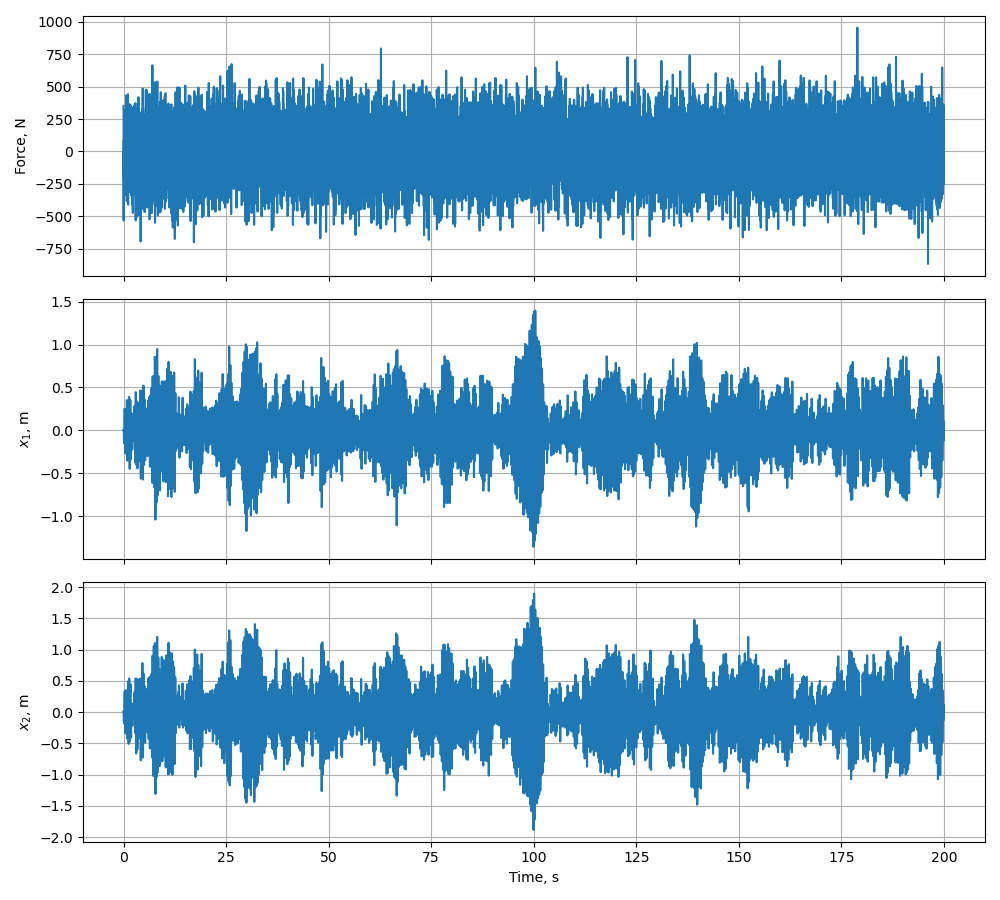

In [3]:
import numpy as np  # import numpy library for numerical calculations
from scipy.interpolate import interp1d  # import interp1d function for interpolation
from scipy.integrate import odeint  # import odeint function for solving ODEs
import matplotlib.pyplot as plt  # import matplotlib library for plotting

# Enable interactive plots
%matplotlib widget

# Create time array
t_span = 200  # [s]
f_sampling = 100  # sampling frequency [Hz]
t_vector = np.arange(0, t_span, 1 / f_sampling)  # time vector [s]

# Generate random force signal
np.random.seed(11)  # set random seed for reproducibility
force_rms = 200  # RMS of the force signal [N]
random_signal = np.random.normal(
    size=len(t_vector)
)  # random signal with normal distribution centered at 0
random_force_signal = random_signal * (
    force_rms / np.sqrt(np.mean(random_signal**2))
)  # scale random signal to desired RMS [N]

# Create interpolated force function
random_force_function = interp1d(
    t_vector, random_force_signal, bounds_error=False, fill_value=0
)

# Solve ODE
initial_state = [0, 0, 0, 0]  # zero-displacement and zero-velocity initial conditions
solution = odeint(
    two_dof_mass_spring_damper, initial_state, t_vector, args=(random_force_function,)
)

# Extract displacements at the two degrees of freedom
displacements = solution[:, :2].T

# Create figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

# Plot force
random_force_signal = random_force_function(t_vector)
axes[0].plot(t_vector, random_force_signal)
axes[0].set_ylabel("Force, N")
axes[0].grid(True)

# Plot displacement
axes[1].plot(t_vector, displacements[0])
axes[1].set_ylabel("$x_1$, m")
axes[1].grid(True)

# Plot velocity
axes[2].plot(t_vector, displacements[1])
axes[2].set_ylabel("$x_2$, m")
axes[2].grid(True)
axes[2].set_xlabel("Time, s")

# Set layout and show plot
plt.tight_layout()
plt.show()

### Data Processing <a name="data-processing"></a>

We define the function `calculate_frf`, which calculates the FRF for each degree of freedom by dividing the FFT of the output displacement by the FFT of the input force. We then calculate the FRF for our data.

In [4]:
from scipy import fft


def calculate_frf(input_signal, output_signal_array):
    """
    Calculate the frequency response function (FRF) for a given input signal and output signal array.

    Parameters:
    input_signal (array): Input signal for which the FRF is calculated.
    output_signal_array (array): Array of output signals for which the FRF is calculated.

    Returns:
    array: Array of FRFs for each output signal.
    """
    # Calculate FFT for input signal
    input_fft = fft.fft(input_signal)

    # Calculate FFT for each output signal and corresponding FRF
    output_fft = np.zeros_like(output_signal_array, dtype=complex)
    frf = np.zeros_like(output_signal_array, dtype=complex)
    for i in range(output_signal_array.shape[0]):
        output_fft[i] = fft.fft(output_signal_array[i])
        frf[i] = output_fft[i] / input_fft

    return frf


# Calculate FRF for the random force signal and the two output signals
frf = calculate_frf(random_force_signal, displacements)

Let's now define the function `plot_spectrum` to plot the magnitude and phase of the FRF, and let's plot our FRF for each degree of freedom.

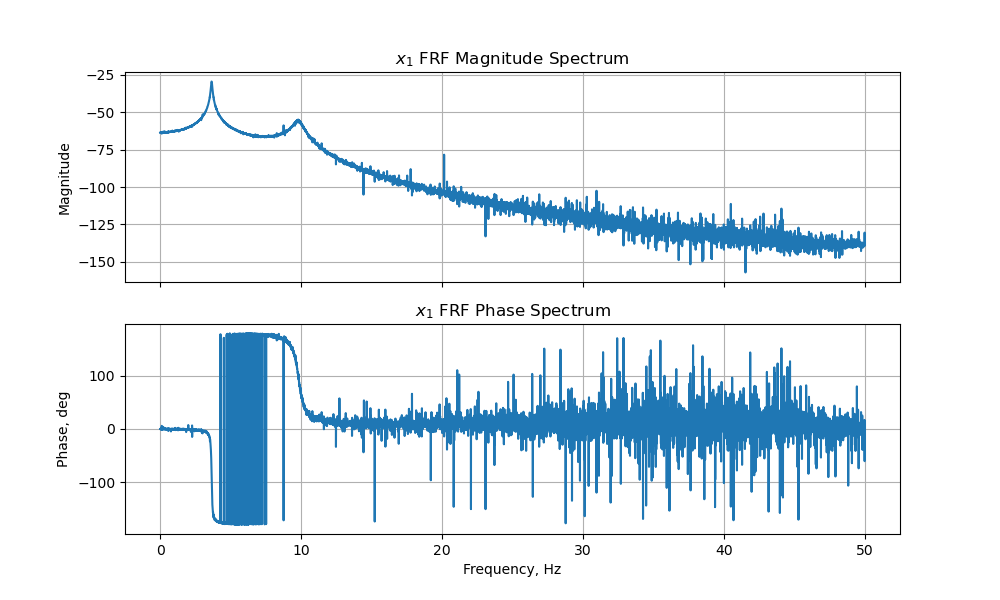

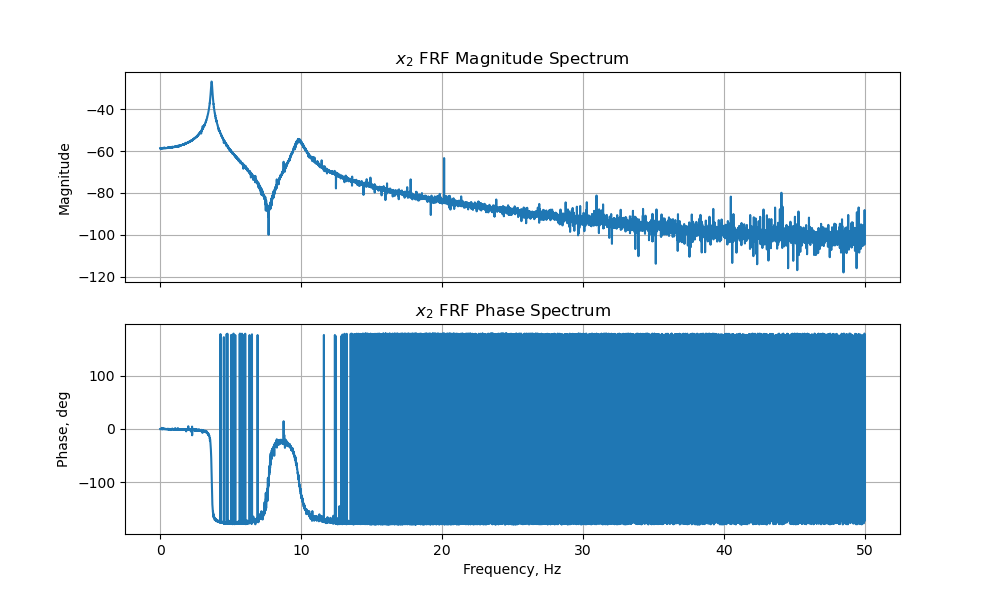

In [5]:
def plot_spectrum(frequencies, spectrum, title):
    """Plot magnitude and phase spectrum of a signal

    Parameters:
    frequencies (array): Frequency vector
    spectrum (array): Complex spectrum values
    title (str): Plot title
    """
    # Get positive frequencies only (since spectrum is symmetric for real signals)
    pos_mask = frequencies >= 0
    pos_freqs = frequencies[pos_mask]
    pos_spectrum = spectrum[pos_mask]

    # Calculate magnitude and phase
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    phase = np.angle(pos_spectrum, deg=True)

    # Create figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db)
    axes[0].set_ylabel("Magnitude")
    axes[0].grid(True)
    axes[0].set_title(f"{title} Magnitude Spectrum")

    # Plot phase
    axes[1].plot(pos_freqs, phase)
    axes[1].set_ylabel("Phase, deg")
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].grid(True)
    axes[1].set_title(f"{title} Phase Spectrum")

    return fig, axes


# Plot FRF spectrum for each degree of freedom
frequencies = np.fft.fftfreq(len(t_vector), 1 / f_sampling)
_, _ = plot_spectrum(frequencies, frf[0], "$x_1$ FRF")
plt.show()
_, _ = plot_spectrum(frequencies, frf[1], "$x_2$ FRF")
plt.show()

Both $x_1$ and $x_2$ FRF magnitude plots clearly reveal the system's two natural frequencies:
- first mode: around 3-4 Hz;
- second mode: around 10 Hz.

The $x_2$ FRF magnitude plot also shows the anti-resonance at around 6-7 Hz.

The phase plots show characteristic $180^\circ$ phase shifts at resonances:
- for $x_1$: phase transitions from $0$ to $-180^\circ$ across the first natural frequency, and from $-180^\circ$ to $-360^\circ$ (so $0^\circ$) across the second natural frequency (phase wrapping causes the jump from $-180^\circ$ to $+180^\circ$);
- for $x_2$: phase transitions from from $0$ to $-180^\circ$ across the first natural frequency, from $-180^\circ$ towards $0^\circ$ at the anti-resonance, and finally back to $-180^\circ$ across the second natural frequency.

Both FRF spectra appear quite clean at low frequencies (except for the phase wrapping affecting the phase plots), and their quality progressively degrades at higher frequencies.

Before calculating the IRF, we try to improve the FRF by applying a Savitzky-Golay filter, similarly to our last notebook.

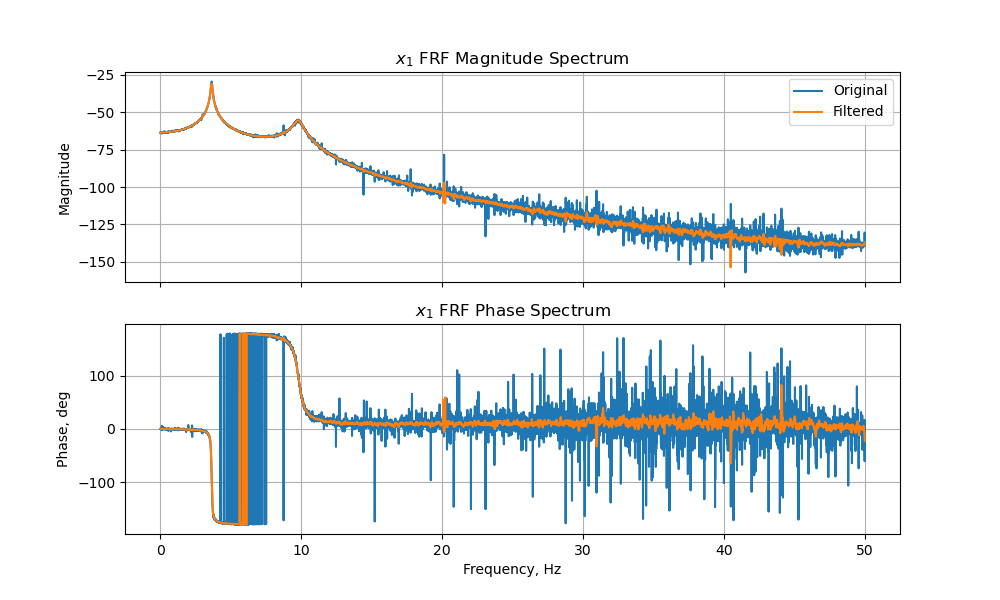

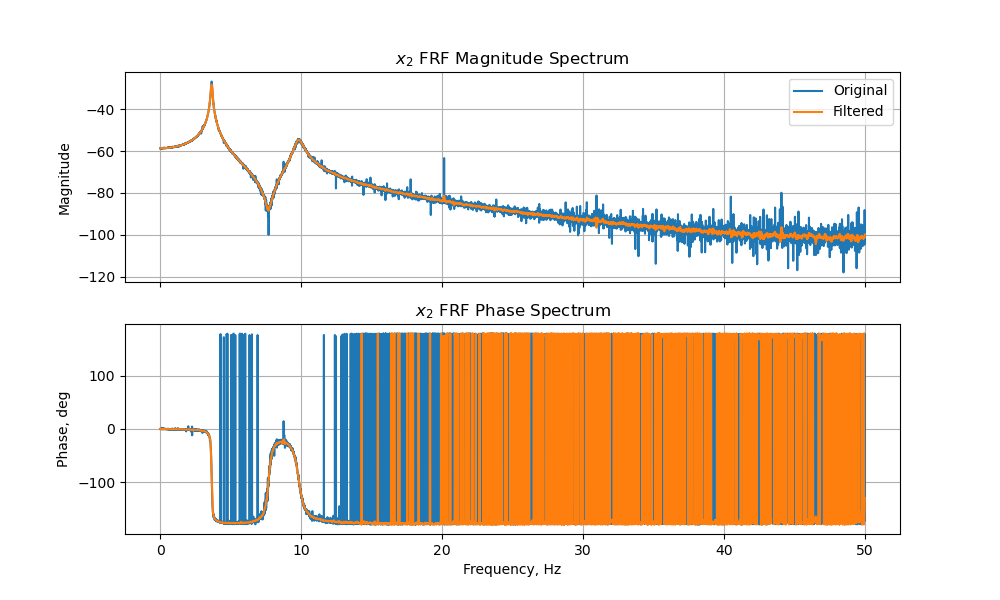

In [6]:
from scipy import signal

# Define Savitzky-Golay filter parameters
window_length = 31
polyorder = 3

# Get positive-frequency portion of the FRF
pos_mask = frequencies >= 0
pos_freqs = frequencies[pos_mask]

# Initialize filtered FRF array
pos_spectrum_filtered = np.zeros((DOF_COUNT, len(pos_freqs)), dtype=complex)

# Iterate over the degrees of freedom
for i in range(DOF_COUNT):
    # Get positive-frequency portion of the FRF
    pos_spectrum = frf[i, pos_mask]

    # Apply Savitzky-Golay filter for smoothing
    real_filtered = signal.savgol_filter(pos_spectrum.real, window_length, polyorder)
    imag_filtered = signal.savgol_filter(pos_spectrum.imag, window_length, polyorder)
    pos_spectrum_filtered[i] = real_filtered + 1j * imag_filtered

    # Plot original FRF to compare with filtered FRF
    fig, axes = plot_spectrum(frequencies, frf[i], f"$x_{i+1:d}$ FRF")

    # Calculate magnitude and phase of the filtered FRF
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum_filtered[i]))
    phase = np.angle(pos_spectrum_filtered[i], deg=True)

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db)
    axes[0].legend(["Original", "Filtered"])

    # Plot phase
    axes[1].plot(pos_freqs, phase)

    # Show plot
    plt.show()

The Savitzky-Golay filter manages to smooth the FRF magnitude and phase plots, eliminating the few fluctuations present at low frequencies and reducing those characterizing the higher-frequency content. The amplitude and location of the resonance peaks remain unchanged, only the anti-resonance peak in the $x_2$ FRF magnitude plot sees a noticeable reduction.

Finally we calculate the Impulse Response Function (IRF) for both the original and filtered FRF data.

In [7]:
# Calculate IRF from original FRF
irf = np.fft.ifft(frf)

# Create full spectrum of filtered FRF by complex conjugate symmetry
full_spectrum_filtered = np.hstack(
    [pos_spectrum_filtered, pos_spectrum_filtered.conj()[:, 1:-1][:, ::-1]]
)

# Calculate IRF from filtered FRF
savgol_irf = fft.ifft(full_spectrum_filtered).real

### Parameter Estimation <a name="parameter-estimation"></a>

We can now estimate the parameters of the system using the LSCE algorithm. We start by defining the function `estimate_lsce_parameters`, which takes as input the IRF and computes the $\beta$ coefficients.

In [8]:
def estimate_lsce_parameters(irf):
    """
    Estimate the Least Squares Complex Exponential (LSCE) parameters

    Parameters:
    irf (array): displacements IRF with shape (2, N)

    Returns:
    array: Estimated LSCE parameters with shape (4, 1)
    """
    # Find number of samples
    N = irf.shape[1]

    # Create output vector
    h = np.atleast_2d(np.hstack((irf[0, 4:], irf[1, 4:]))).T

    # Create observation matrix
    H = np.vstack(
        (
            np.vstack(
                (
                    [
                        irf[0, 0 : N - 4],
                        irf[0, 1 : N - 3],
                        irf[0, 2 : N - 2],
                        irf[0, 3 : N - 1],
                    ]
                )
            ).T,
            np.vstack(
                (
                    [
                        irf[1, 0 : N - 4],
                        irf[1, 1 : N - 3],
                        irf[1, 2 : N - 2],
                        irf[1, 3 : N - 1],
                    ]
                )
            ).T,
        )
    )

    # Calculate the LSCE parameters
    betas = np.linalg.lstsq(H, -h)[0]

    # Return the LSCE parameters
    return betas

Then we define the function `estimate_modal_parameters` that computes the natural frequency and damping ratio of the system from the $\beta$ coefficients.

In [9]:
def estimate_modal_parameters(betas, fs):
    """
    Estimate the modal parameters. Results are sorted by natural frequency.

    Parameters:
    betas (array): Estimated LSCE parameters with shape (pole_count, 1)
    fs (float): Sampling frequency [Hz]

    Returns:
    array: Natural frequencies of the modes [rad/s]
    array: Damping ratios of the modes
    array: Discrete-time poles
    """
    # Calculate the discrete-time poles
    poly_coeffs = np.hstack((1, betas[::-1, 0]))
    lambdas = np.roots(poly_coeffs)

    # The poles come in complex conjugate pairs for underdamped systems
    # Sort the poles to identify conjugate pairs

    # We'll pair the poles based on their absolute values (magnitudes)
    # First, sort by magnitude
    sort_indices = np.argsort(np.abs(lambdas))
    sorted_lambdas = lambdas[sort_indices]

    # Group the poles with similar magnitudes
    mode_count = betas.shape[0] // 2  # number of modes = number of betas / 2
    omegas = np.zeros(mode_count)
    zetas = np.zeros(mode_count)

    # Process each mode (pair of poles)
    for i in range(mode_count):
        # Take consecutive poles after sorting - they should be a conjugate pair
        lambda1 = sorted_lambdas[2 * i]
        lambda2 = sorted_lambdas[2 * i + 1]

        # Verify these are actually a conjugate pair
        # If not, you might need a more sophisticated pairing algorithm
        if not np.isclose(np.abs(lambda1), np.abs(lambda2), rtol=1e-4):
            print(
                f"Warning: Poles {lambda1} and {lambda2} might not be a conjugate pair"
            )

        # Calculate natural frequency and damping ratio
        # We take the square root of the product of logarithms
        omega = fs * np.sqrt(np.log(lambda1) * np.log(lambda2))

        # Calculate the damping ratio using the product of the poles
        zeta = -fs * np.log(lambda1 * lambda2) / (2 * omega)

        # Take the real part of the natural frequency and damping ratio
        omegas[i] = np.real(omega)
        zetas[i] = np.real(zeta)

    # Sort the modal parameters by natural frequency
    sort_indices = np.argsort(omegas)
    sorted_omegas = omegas[sort_indices]
    sorted_zetas = zetas[sort_indices]

    # Sort the poles by natural frequency
    resorted_lambdas = np.zeros_like(lambdas)
    for i in range(mode_count):
        resorted_lambdas[2 * i] = sorted_lambdas[sort_indices[i] * 2]
        resorted_lambdas[2 * i + 1] = sorted_lambdas[sort_indices[i] * 2 + 1]

    # Return modal parameters and lambdas
    return sorted_omegas, sorted_zetas, resorted_lambdas

Finally, we can define the function `estimate_mode_shapes` to estimate the mode shapes from the residues, which in turn are obtained from the discrete-time poles $\lambda$.

In [10]:
def estimate_mode_shapes(irf, lambdas, drive_index=1):
    """
    Estimate mode shapes from the impulse response function (IRF) and poles

    Parameters:
    irf (array): Displacements IRF with shape (number of DOFs, number of IRF samples)
    lambdas (array): Discrete-time poles with shape (number of poles,)
    drive_index (int): Index of the drive signal, defaults to 1 because force is applied at the second DOF

    Returns:
    array: Mode shapes sorted by frequency with shape (number of DOFs, number of modes)
    """
    # Calculate the number of poles and modes
    pole_count = lambdas.shape[0]  # number of poles = number of lambdas
    mode_count = pole_count // 2  # number of modes = number of poles / 2

    # Initialize array of residues
    residues = np.zeros((DOF_COUNT, pole_count), dtype=complex)

    # Assemble matrix of lambdas
    lambda_matrix = np.vstack([l ** np.arange(pole_count) for l in lambdas]).T

    # Iterate over each degree of freedom
    for i in range(DOF_COUNT):
        # Take the first pole_count time samples
        h = irf[i, :pole_count].T
        # Calculate residues
        residues[i] = np.linalg.solve(lambda_matrix, h)

    # Use the driving point residues to normalize mode shapes
    # Scale factor is square root of driving point residues
    # a_ir = A_ir / sqrt(A_2r)
    scale_factors = np.sqrt(residues[drive_index, :])

    # Handle zero residues to avoid division by zero
    scale_factors[np.abs(scale_factors) < 1e-10] = 1.0

    # Initialize array of mode shapes (rows = degrees of freedom, columns = modes)
    modes = np.zeros((DOF_COUNT, mode_count))

    # Iterate over each degree of freedom
    for i in range(DOF_COUNT):
        # Calculate ratios of residues to scale factors
        ratios = residues[i, :] / scale_factors
        # Extract every second element (since poles are complex conjugate pairs) and take the real part
        modes[i, :] = ratios[::2].real

    # Normalize mode shapes to unit length
    norms = np.linalg.norm(modes, axis=0)
    modes /= norms

    # Return the mode shapes
    return modes

We apply these functions to the IRF obtained from the raw FRF and print the estimated natural frequency and damping ratio.

In [11]:
# Estimate LSCE parameters and modal parameters
betas = estimate_lsce_parameters(irf)
omegas, zetas, lambdas = estimate_modal_parameters(betas, f_sampling)

# Take sorted true natural frequencies and damping ratiosn for comparison
true_freq_sort_indices = np.argsort(natural_frequencies)
sorted_natural_frequencies = natural_frequencies[true_freq_sort_indices]
sorted_damping_ratios = damping_ratios[true_freq_sort_indices]

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(DOF_COUNT):
    print(f"Mode {i+1:d}")
    print(f"True natural frequency: {sorted_natural_frequencies[i]:.2f} rad/s")
    print(f"Estimated natural frequency: {omegas[i]:.2f} rad/s")
    print(
        f"Percentage error: {100 * (omegas[i]/sorted_natural_frequencies[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {sorted_damping_ratios[i]:.2f}")
    print(f"Estimated damping ratio: {zetas[i]:.2f}")
    print(f"Percentage error: {100 * (zetas[i]/sorted_damping_ratios[i] - 1):.2f}%\n")

Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 23.02 rad/s
Percentage error: 0.44%
True damping ratio: 0.01
Estimated damping ratio: 0.04
Percentage error: 259.42%

Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 68.57 rad/s
Percentage error: 11.11%
True damping ratio: 0.03
Estimated damping ratio: 0.24
Percentage error: 661.78%



The natural frequency results are quite close to the true values, in particular for the first mode. However, the damping ratios are completely off for both modes.

Let's find the mode shapes.

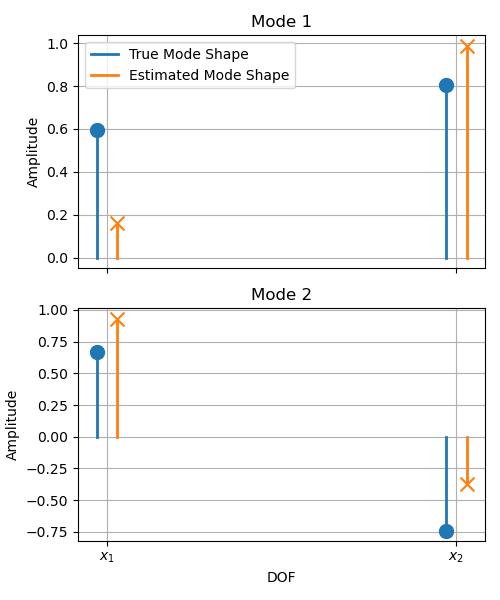

In [12]:
# Calculate estimated mode shapes
estimated_modes = estimate_mode_shapes(irf, lambdas)

# Sort true mode shapes based on true natural frequencies
sorted_true_modes = np.zeros_like(eigenvectors)
for i in range(DOF_COUNT):
    sorted_true_modes[:, i] = eigenvectors[:, true_freq_sort_indices[i]]

# Get default matlpotlib colors
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def plot_mode_shapes(true_modes, est_modes):
    """
    Plot true vs estimated mode shapes

    Parameters:
    true_modes: array of shape (number of DOFs, number of modes) containing true mode shapes
    est_modes: array of shape (number of DOFs, number of modes) containing estimated mode shapes
    """
    # Create x-axis vector with node positions (x1, x2)
    node_positions = np.arange(1, DOF_COUNT + 1)

    # Define offset for estimated mode shapes
    offset = 0.03

    # Create a figure with a subplot for each mode
    mode_count = true_modes.shape[1]
    fig, axes = plt.subplots(mode_count, 1, figsize=(5, 3 * mode_count), sharex=True)

    # Iterate over each mode
    for i in range(mode_count):
        # Ensure mode shapes are oriented in the same direction
        if np.dot(true_modes[:, i], est_modes[:, i]) < 0:
            est_modes[:, i] = -est_modes[:, i]

        # Iterate over each degree of freedom
        for j in range(DOF_COUNT):
            # Plot component of current degree of freedom for current mode shape
            true_line = axes[i].plot(
                np.array([j + 1, j + 1]) - offset,
                [0, true_modes[j, i]],
                color=COLORS[0],
                label="True Mode Shape",
                linewidth=2,
            )
            est_line = axes[i].plot(
                np.array([j + 1, j + 1]) + offset,
                [0, est_modes[j, i]],
                color=COLORS[1],
                label="Estimated Mode Shape",
                linewidth=2,
            )

            # Plot markers
            axes[i].scatter(
                (j + 1) - offset, true_modes[j, i], color=COLORS[0], marker="o", s=100, zorder=5
            )
            axes[i].scatter(
                (j + 1) + offset,
                est_modes[j, i],
                color=COLORS[1],
                marker="x",
                s=100,
                zorder=5,
            )

        # Add labels and legend
        axes[i].set_title(f"Mode {i+1}")
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(True)

    # Add labels and legend
    axes[0].legend(
        [true_line[0], est_line[0]], ["True Mode Shape", "Estimated Mode Shape"]
    )
    axes[-1].set_xlabel("DOF")
    axes[-1].set_xticks(node_positions)
    axes[-1].set_xticklabels([f"$x_{i+1}$" for i in range(DOF_COUNT)])

    # Set layout and show plot
    plt.tight_layout()
    plt.show()


# Plot true vs estimated mode shapes
plot_mode_shapes(sorted_true_modes, estimated_modes)

The mode shape estimates capture the fundamental characteristics of each mode. Mode 1 is correctly identified as the in-phase mode, with both masses moving in the same direction. However, the amplitude at $x_2$ is overestimated, while the amplitude at $x_1$ is underestimated. Also mode 2 is correctly identified as the out-of-phase mode, with the masses movingin opposite direction. In this case, the amplitude at $x_1$ is overestimated, while the amplitude at $x_2$ is underestimated.

Now we apply the estimation to the IRF obtained from the filtered FRF.

Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 22.79 rad/s
Percentage error: -0.55%
True damping ratio: 0.01
Estimated damping ratio: 0.02
Percentage error: 32.06%

Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 64.61 rad/s
Percentage error: 4.69%
True damping ratio: 0.03
Estimated damping ratio: 0.10
Percentage error: 237.46%



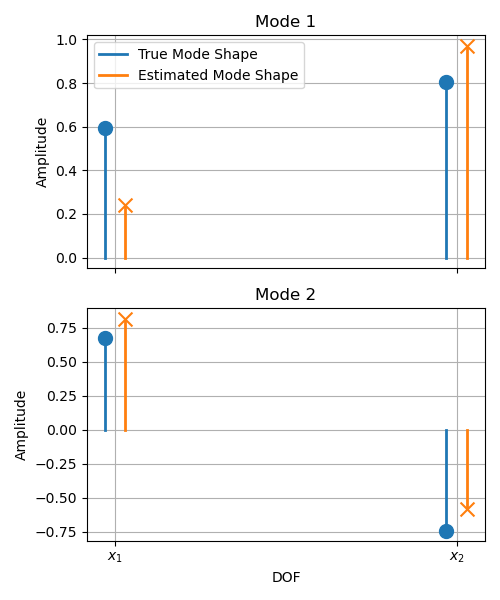

In [13]:
# Estimate LSCE parameters and modal parameters
betas = estimate_lsce_parameters(savgol_irf)
omegas, zetas, lambdas = estimate_modal_parameters(betas, f_sampling)

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(DOF_COUNT):
    print(f"Mode {i+1:d}")
    print(f"True natural frequency: {sorted_natural_frequencies[i]:.2f} rad/s")
    print(f"Estimated natural frequency: {omegas[i]:.2f} rad/s")
    print(
        f"Percentage error: {100 * (omegas[i]/sorted_natural_frequencies[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {sorted_damping_ratios[i]:.2f}")
    print(f"Estimated damping ratio: {zetas[i]:.2f}")
    print(f"Percentage error: {100 * (zetas[i]/sorted_damping_ratios[i] - 1):.2f}%\n")

# Calculate estimated mode shapes
estimated_modes = estimate_mode_shapes(savgol_irf, lambdas)

# Plot true vs estimated mode shapes
plot_mode_shapes(sorted_true_modes, estimated_modes)

The filtering improves the estimate of the modal parameters, especially for the natural frequency of the second mode which now is only 4.7% off the true value. Despite the improvement, the damping ratios are still far from the true values. Also the mode shape estimates improve, but discrepancies remain, particularly in the first mode.

The above modal identification results suggest a systematic issue in the damping estimation process rather than random noise effects. A number of causes can be identified for these results:
- the random noise excitation might not provide consistent energy across the frequency spectrum, leading to inaccuracies in the FRF calculation;
- the calculation of the input and output FFTs might introduce significant spectral leakage, broadening the resonance peaks and consequently overestimating damping;
- the direct calculation of the FRFs through simple element-wise division of output and input FFTs might amplify the noise significantly where the energy of the input signal is low, especially at higher frequencies;
- damping estimation with the LSCE algorithm is highly sensitive to noise, especially for higher-frequency modes.

As far as the mode shape estimation is concerned, the process relies on accurte calculation of the residues, which in turn depends on the accuracy of the estimated poles and the quality of the IRF derived from the FRF. Small errors in the poles and FRF can propagate to large errors in the residues and consequently in the mode shapes.

To address these issues, we are going to use a more advanced method for the calculation of the FRF, which involves the concepts of windowing, power spectral densities, estimators, segmentation, averaging and overlaps.

## Parameter Estimation with Improved FRF Calculation <a name="estimation-improved"></a>

***

From our last notebook, we know that when we compute the DFT of a finite-length signal $x(t)$, we are effectively multiplying the infinitely repeating extention of the signal $x_\infty(t)$, by a rectangular window function $w(t)$:

$$x(t) = x_\infty(t) w(t).$$

In frequency domain, this multiplication becomes a convolution:

$$X(\omega) = X_\infty(\omega) * W(\omega),$$

where $W(\omega)$ is the Fourier transform of the rectangular window function $w(t)$. We know that this Fourier transform is a sinc function, which is responsible for spectral leakage due to its main and side lobes. The width of the central lobe can be reduced by taking a longer measurement of the signal, and the narrower the central lobe, the less spectral leakage we have.

An alternative approach to reduce spectral leakage is the so-called _windowing_ technique, which essentially consists in replacing the rectangular window with a window function that tapers the signal at its edges. The reason for this choice is that this kind of window function has a Fourier transform that reduces spectral leakage compared to the Fourier transform of the rectangular window.

A common and particularly effective window for modal analysis is the Hann window, which, for a discrete-time signal of length $N$, is defined as:

$$w(n) = \frac{1}{2} \left(1 - \cos\left(\frac{2\pi n}{N-1}\right)\right), \quad 0 \leq n \leq N-1,$$

where $n$ is the sample index.

Let's visualize what the Hann window looks like in the time domain and compare its Fourier transform with that of the rectangular window.

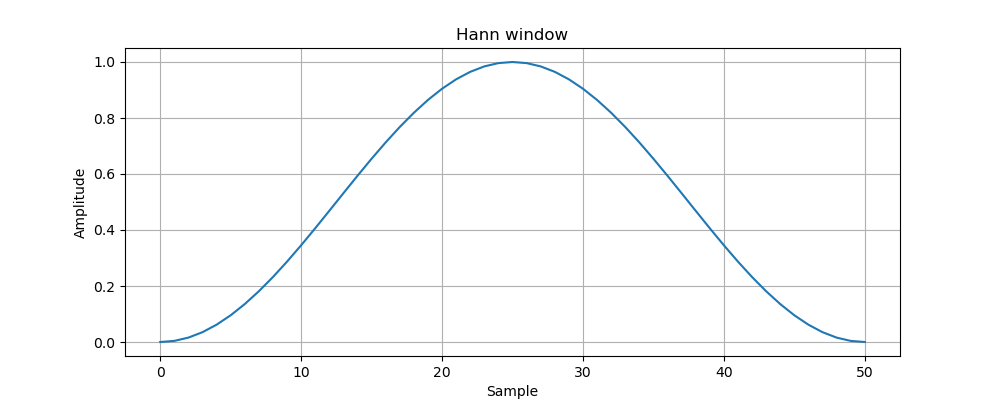

C:\Users\qa21944\AppData\Local\Temp\ipykernel_28656\3815720988.py:35: RuntimeWarning: divide by zero encountered in log10
  hann_response = 20 * np.log10(np.abs(fft.fftshift(hann_fft / np.abs(hann_fft).max())))


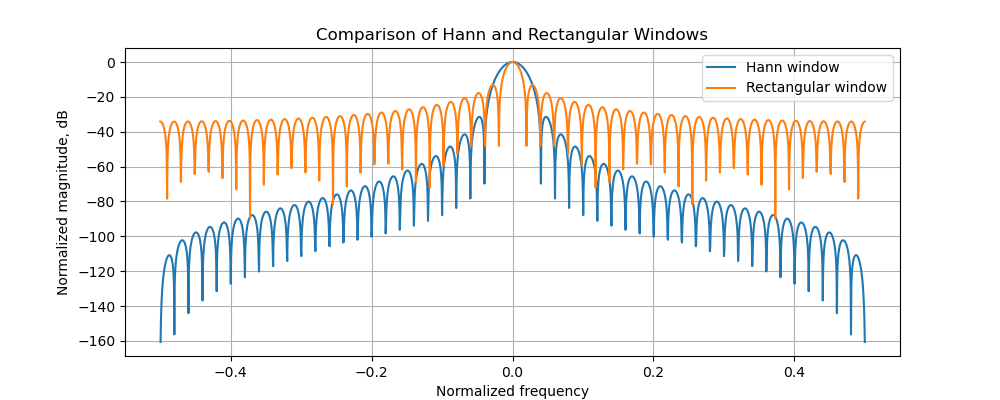

In [14]:
# Create window functions with a reasonable number of points
time_point_count = 51  # Same size as in scipy's documentation example
hann_window = signal.windows.hann(time_point_count)
rect_window = signal.windows.boxcar(time_point_count)

# Plot the Hann window
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hann_window)
ax.set_title("Hann window")
ax.set_ylabel("Amplitude")
ax.set_xlabel("Sample")
ax.grid(True)
plt.show()

# Add zero-padding for smoother frequency representation
# This doesn't add new information or improve true frequency resolution
# It allows to interpolate between frequency bins for a smoother visual representation
fft_point_count = 2048

# Calculate FFTs with proper normalization
# The division by (len(window)/2.0) is a standard normalization in spectral analysis
# This normalization ensures that the amplitude of spectral peaks correctly represents
# the amplitude of time-domain signals, accounting for how energy spreads across FFT bins
# For real signals, the factor of 2 accounts for energy in negative frequencies
hann_fft = fft.fft(hann_window, fft_point_count) / (len(hann_window) / 2.0)
rect_fft = fft.fft(rect_window, fft_point_count) / (len(hann_window) / 2.0)

# Shift, normalize to maximum amplitude, and convert to dB
# This sequence of operations:
# 1. Divides all values by the maximum amplitude (A / abs(A).max()) → peak becomes 1.0
# 2. Takes the absolute value to get magnitude response
# 3. Converts to decibels with 20*log10() → peak becomes 0 dB (because log10(1) = 0)
# 4. Applies fftshift to center the spectrum at zero frequency
# This normalization makes window functions directly comparable (all peak at 0 dB)
hann_response = 20 * np.log10(np.abs(fft.fftshift(hann_fft / np.abs(hann_fft).max())))
rect_response = 20 * np.log10(np.abs(fft.fftshift(rect_fft / np.abs(rect_fft).max())))

# Create normalized frequency axis (frequency/sampling frequency, thus -0.5 to 0.5)
# This is the standard way to visualize window spectra, making them
# independent of any specific sampling rate
freq = np.linspace(-0.5, 0.5, fft_point_count)

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(freq, hann_response, label="Hann window")
plt.plot(freq, rect_response, label="Rectangular window")
plt.title("Comparison of Hann and Rectangular Windows")
plt.ylabel("Normalized magnitude, dB")
plt.xlabel("Normalized frequency")
plt.legend()
plt.grid(True)
plt.show()

As we can see, the time-domain Hann window is symmetric and has a smooth tapering at the edges. The resulting frequency spectrum has significantly reduced sidelobes compared to those of the rectangular window, decreasing spectral leakage to frequencies far from the frequency component being convolved. However, this improvement comes with a trade-off. First, it broadens the width of the main lobe, meaning that leakage to nearby frequencies increases. This in turn corresponds to a decrease of the effective frequency resolution and to an increase of the uncertainty in frequency estimation. Second, the effective length of the signal is reduced, as the signal is attenuated at the edges. This also contributes to the reduction of the effective frequency resolution. Nevertheless, the overall reduction of spectral leakage makes the Hann window a good choice for modal analysis.

In addition to windowing, to further improve the calculation of the FRF, we must consider how energy distributes across frequencies, which brings us to the concept of _power spectral density_ (PSD). The PSD describes how the power of a signal is distributed across different frequencies, providing a more stable representation than the direct Fourier transform for random or noisy signals.

For a discrete-time signal $x(n)$, the PSD can be estimated directly from the Fourier transform of the signal, which is called the _periodogram_ estimate:

$$P_{xx}(\omega) = \frac{1}{N}X(\omega)^*X(\omega) = \frac{1}{N}|X(\omega)|^2,$$

where $X(\omega)$ is the DFT of the signal $x(n)$, $^*$ denotes the complex conjugate, and $N$ is the signal length.

While the magnitude of the DFT ($|X(\omega)|$) tells us the amplitude of frequency components, the PSD (proportional to $|X(\omega)|^2$) represents the energy or power contained at each frequency. This distinction is critical because power relates directly to the physical energy in vibrating systems. Furthermore, unlike the raw DFT magnitude which can vary significantly between measurements due to random noise, the PSD provides a more consistent representation of a system's frequency characteristics when properly estimated through techniques like Welch's method, as we will see later.

For modal analysis, we're interested not just in the power distribution of individual signals, but in the relationship between input and output signals. This relationship is captured by the cross-power spectral density (CPSD), which measures the correlation between two signals across frequencies and can be estimated from the Fourier transforms of the input and output signals:

$$P_{xy}(\omega) = \frac{1}{N}X(\omega)^*Y(\omega),$$

where $Y(\omega)$ is the DFT of the output signal $y(n)$.

The CPSD is a complex-valued function that captures both magnitude and phase relationships between input and output signals. Where the DFT only shows which frequencies exist in each signal independently, the CPSD shows how these frequencies interact between signals, as the phase of the CPSD specifically represents the phase difference between input and output signals. The PSD and CPSD form the foundation for more robust FRF estimation methods, particularly in the presence of noise—a persistent challenge in experimental modal analysis.

In ideal conditions, the FRF could be calculated by simply dividing the Fourier transform of the output by the Fourier transform of the input. However, real measurements are invariably contaminated by noise, requiring more sophisticated approaches. The _H1 estimator_ addresses this challenge by using the ratio of cross-power spectral density to input auto-power spectral density:

$$H_1(\omega) = \frac{P_{xy}(\omega)}{P_{xx}(\omega)}$$

This formulation offers a critical advantage: it minimizes the effect of noise in the output signal. To understand why, consider that the CPSD $P_{xy}(\omega)$ correlates input and output signals, inherently filtering out components in the output that don't correlate with the input (i.e., noise). By dividing by the input PSD $P_{xx}(\omega)$, we normalize this relationship, yielding a more accurate FRF.

Mathematically, if we denote the measured output as $y(n) = y_{true}(n) + n_y(n)$, where $y_{true}(n)$ is the true response and $n_y(n)$ is the output noise, then:

$$P_{xy}(\omega) = P_{x,y_{true}}(\omega) + P_{x,n_y}(\omega)$$

If the input signal and output noise are uncorrelated (a reasonable assumption in controlled experiments), then $P_{x,n_y}(\omega) \approx 0$, leaving:

$$H_1(\omega) \approx \frac{P_{x,y_{true}}(\omega)}{P_{xx}(\omega)}$$

This noise-rejection property makes the H1 estimator particularly valuable for modal analysis, where accurate damping estimation is sensitive to noise contamination. By reducing the influence of noise, the H1 estimator helps prevent the artificial broadening of resonance peaks that leads to overestimation of damping ratios—precisely the issue observed in our current results.

While the H1 estimator provides theoretical advantages, its practical implementation must address the statistical nature of PSD estimation. A single periodogram estimate of the PSD is notoriously noisy, exhibiting high variance that can obscure the true spectral features. This high variance occurs because each frequency bin's estimate is essentially based on a single realization of a random process, making it susceptible to the random nature of noise. Welch's method addresses this limitation through clever application of _segmentation_, _overlapping_, and _averaging_.

The approach begins by dividing the time signal into multiple segments, each of which will yield an individual periodogram estimate. For a signal $x(n)$ of length $N$, we create $M$ segments, each of length $L$:

$$x_k(n) = x(n + kD) \quad \text{for } 0 \leq n \leq L-1 \text{ and } 0 \leq k \leq M-1$$

where $D$ is the distance between consecutive segment starts, determined by the desired overlap, and $k$ is the segment index.

Each segment is then windowed individually:

$$x_{w,k}(n) = x_k(n) \cdot w(n)$$

After computing the periodogram for each windowed segment, we average these periodograms to obtain the Welch PSD estimate:

$$P_\text{Welch}(\omega) = \frac{1}{M} \sum_{k=0}^{M-1} P_k(\omega),$$

where $P_k(\omega)$ is the periodogram of the $k$-th windowed segment. This averaging process substantially reduces the variance of the PSD estimate, resulting in a smoother, more reliable representation of the signal's frequency content. The smoother PSD translates to cleaner FRFs, enabling more accurate identification of resonance features and, consequently, more precise modal parameter estimation.

However, segmentation introduces a new challenge: by dividing the signal, we effectively discard some of the information contained in the original continuous signal, particularly at the segment boundaries. Overlapping segments partially recovers this lost information. When segments overlap, a portion of the signal appears in multiple segments, ensuring that features near segment boundaries are adequately represented in the final averaged estimate.

The overlap percentage represents a tradeoff: too little overlap fails to recover the boundary information, while excessive overlap introduces redundancy and correlations between segments, diminishing the statistical benefits of averaging. For the Hann window, an overlap of 50% is mathematically optimal, as it ensures that the sum of the overlapped windows equals a constant:

$$\sum_{k=0}^{M-1} w(n + kD) = \text{constant} \quad \text{for } D = L/2$$

This property, known as constant-overlap-add (COLA), ensures that all samples in the original signal contribute equally to the final spectral estimate, preserving the signal's energy distribution.

The practical implementation of this improved FRF calculation method requires careful consideration of segment length, which directly impacts frequency resolution. The resolution in frequency is:

$$\Delta f = \frac{f_s}{L}$$

where $f_s$ is the sampling frequency and $L$ is the segment length. Longer segments provide finer frequency resolution, enabling better distinction between closely spaced modes—a critical consideration in modal analysis where accurate mode separation is essential.

However, longer segments reduce the number of segments available for averaging (for a fixed signal length), increasing the variance of the spectral estimate. This creates a fundamental tradeoff between frequency resolution (bias) and statistical stability (variance) that must be carefully balanced based on the specific characteristics of the system under study.

For modal analysis, a practical guideline is to select a segment length that makes $\Delta f$ at least 4-5 times smaller than the frequency separation of adjacent modes. This ensures adequate resolution while still allowing sufficient averaging to produce stable FRFs.

In summary, the improved FRF calculation approach integrates the following techniques:

1. **Time-domain windowing** reduces spectral leakage, providing cleaner spectral estimates with more accurate resonance features.
2. **Segmentation and averaging** (Welch's method) reduce the variance of spectral estimates, yielding more stable FRFs less affected by random noise.
3. **Overlapping segments** preserve information at segment boundaries, ensuring comprehensive representation of the signal's characteristics.
4. **The H1 estimator** mitigates the effects of output noise, providing more accurate FRFs even in noisy measurement conditions.

Let's now apply these techniques to our synthetic data and evaluate the impact on the modal parameter estimation.

### Data Processing <a name="data-processing-improved"></a>

We implement the improved FRF calculation approach described above in the function `calculate_improved_frf`. The calculation of the PSD of the input signal and of the CPSD between the input and output signals is performed using the functions `welch` and `cpsd` from the `scipy.signal` module, which already implement windowing, segmentation, overlapping, and averaging. Finally, the function computes the H1 estimator of the FRF for each degree of freedom.

In [15]:
def calculate_improved_frf(
    input_signal, output_signal_array, fs, window="hann", nperseg=None, noverlap=None
):
    """
    Calculate the Frequency Response Function (FRF) using SciPy's implementation of Welch's method.

    This function computes the H1 estimator: H1(f) = Gxy(f)/Gxx(f), where:
    - Gxy(f) is the cross-spectral density between input and output
    - Gxx(f) is the power spectral density of the input

    Parameters:
    -----------
    input_signal : array_like
        Input force signal
    output_signal_array : ndarray
        Array of output displacement signals with shape (n_outputs, n_samples)
    fs : float
        Sampling frequency of the signals
    window : str or tuple or array_like
        Window specification for the spectral estimation (default: 'hann')
    nperseg : int, optional
        Length of each segment (default: min(N, 256) where N is signal length)
    noverlap : int, optional
        Number of points to overlap between segments (default: nperseg//2)

    Returns:
    --------
    freqs : ndarray
        Array of sample frequencies
    frf : ndarray
        Array of FRFs for each output signal with shape (n_outputs, n_frequencies)
    """
    from scipy import signal

    n_outputs = output_signal_array.shape[0]
    frfs = []

    # Process each output channel
    for i in range(n_outputs):
        # Calculate cross-spectral density between input and output
        # This gives us Gxy(f)
        f, Gxy = signal.csd(
            input_signal,
            output_signal_array[i],
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate power spectral density of the input
        # This gives us Gxx(f)
        _, Gxx = signal.welch(
            input_signal,
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            return_onesided=False,
        )

        # Calculate H1 estimator: H1(f) = Gxy(f)/Gxx(f)
        frf_channel = Gxy / Gxx
        frfs.append(frf_channel)

    return f, np.array(frfs)

Let's calculate the improved FRF for our synthetic data and plot the magnitude and phase of the FRF for each degree of freedom.

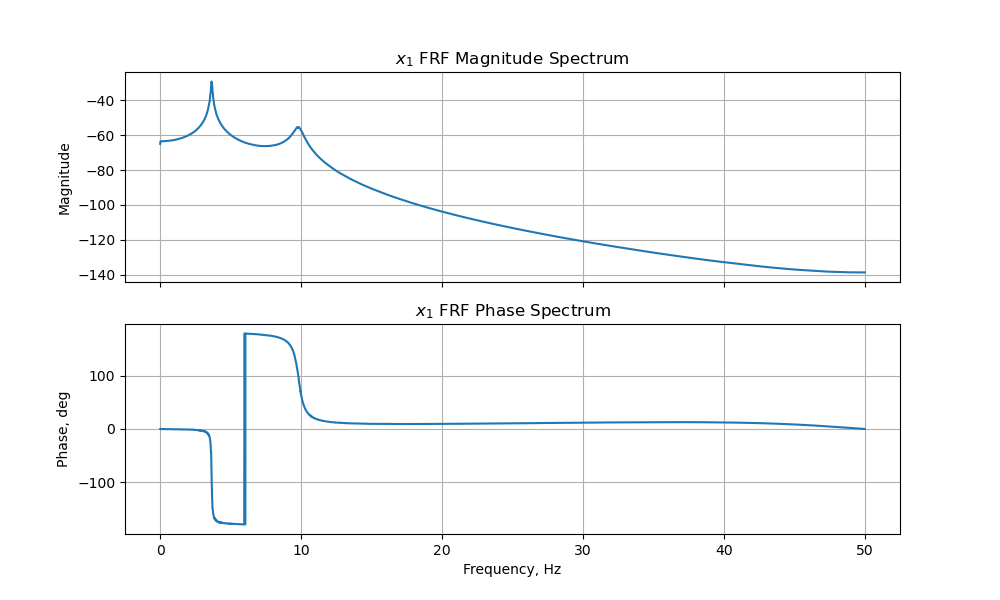

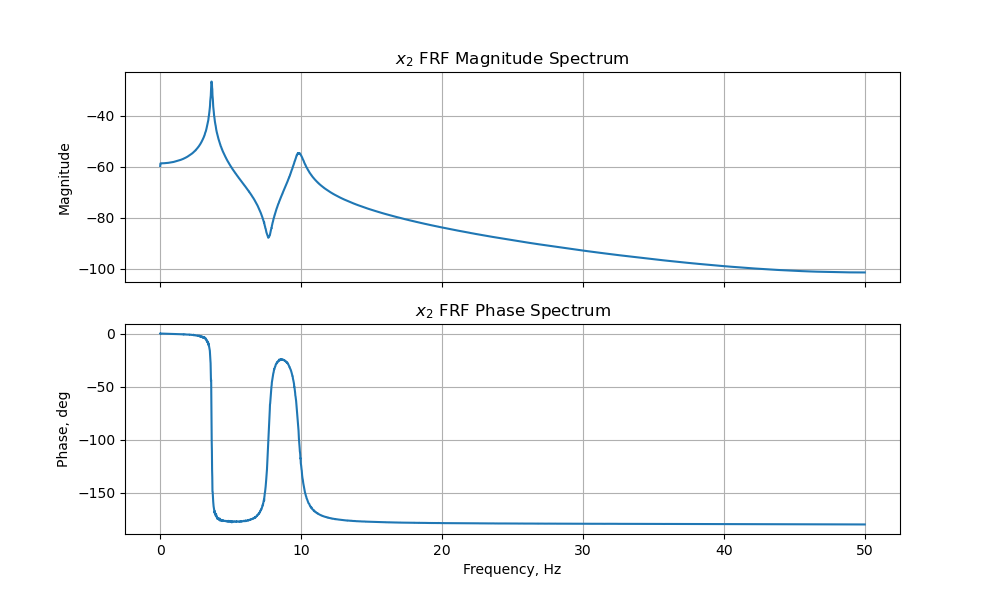

In [16]:
# Calculate improved FRF
frequencies, frf = calculate_improved_frf(
    random_force_signal, displacements, f_sampling, nperseg=7500
)

# Plot FRF spectrum for each degree of freedom
_, _ = plot_spectrum(frequencies, frf[0], "$x_1$ FRF")
plt.show()
_, _ = plot_spectrum(frequencies, frf[1], "$x_2$ FRF")
plt.show()

We can clearly see that the improved FRF calculation approach has virtually removed all noise from the FRF, providing a much cleaner representation of the system's frequency response also at higher frequencies.

### Parameter Estimation <a name="parameter-estimation-improved"></a>

We calculate the IRF from the improved FRF and estimate the modal parameters and the mode shapes using the same functions that we employed earlier.

Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 22.78 rad/s
Percentage error: -0.58%
True damping ratio: 0.01
Estimated damping ratio: 0.01
Percentage error: 0.65%

Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 64.24 rad/s
Percentage error: 4.10%
True damping ratio: 0.03
Estimated damping ratio: 0.09
Percentage error: 199.06%



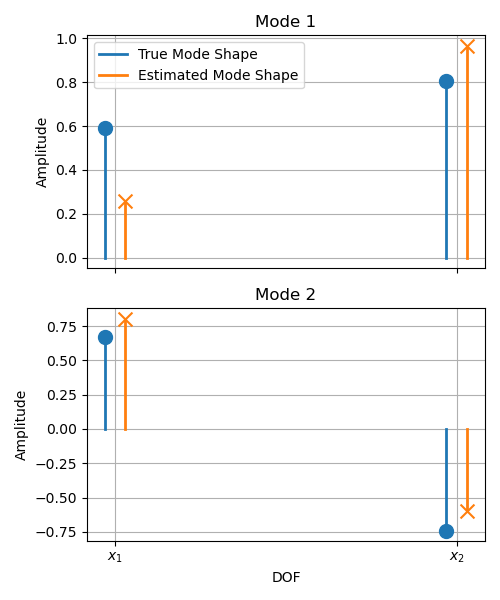

In [17]:
# Calculate IRF
irf = np.fft.ifft(frf, axis=1).real

# Estimate LSCE parameters and modal parameters
betas = estimate_lsce_parameters(irf)
omegas, zetas, lambdas = estimate_modal_parameters(betas, f_sampling)

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(DOF_COUNT):
    print(f"Mode {i+1:d}")
    print(f"True natural frequency: {sorted_natural_frequencies[i]:.2f} rad/s")
    print(f"Estimated natural frequency: {omegas[i]:.2f} rad/s")
    print(
        f"Percentage error: {100 * (omegas[i]/sorted_natural_frequencies[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {sorted_damping_ratios[i]:.2f}")
    print(f"Estimated damping ratio: {zetas[i]:.2f}")
    print(f"Percentage error: {100 * (zetas[i]/sorted_damping_ratios[i] - 1):.2f}%\n")

# Calculate estimated mode shapes
estimated_modes = estimate_mode_shapes(irf, lambdas)

# Plot true vs estimated mode shapes
plot_mode_shapes(sorted_true_modes, estimated_modes)

The above results show a significant success in the estimation of the damping ratio of the first mode, which is now only 0.65% off the true value, compared to the 32% error obtained previously. However, we observe only mild improvements for the modal parameters of the second mode and for the mode shapes. These persistent challenges stem from several fundamental limitations in our current approach.

First, our implementation assumes a fixed model order based on the theoretical understanding of our 2-DOF system (4 poles total). However, this minimum-order model doesn't account for the numerical complexities introduced during data processing. The estimation process is inherently sensitive to small variations in the IRF, particularly for higher-frequency modes like Mode 2. Even with our improved FRF, these sensitivities remain, suggesting that a more flexible approach to model order selection might yield better results.

Another critical issue lies in the conditioning of our parameter estimation problem. The LSCE algorithm involves solving a least squares problem with an observation matrix $\mathbf{H}$ formed from the IRF samples. The conditioning of our least squares problem is quantified by the condition number of matrix $\mathbf{H}$ and indicates how sensitive the solution is to small changes in the input data. If the problem has poor conditioning, it means that even tiny measurement errors or numerical inaccuracies can cause dramatically incorrect parameter estimates, especially for higher-frequency modes. Our least-squares problem can have poor conditioning for a number of reasons.

First, $\mathbf{H}$ has a Block-Toeplitz sturcture, that is to say a shifted pattern where each row contains the same sequence offset by one sample. This creates strong correlations between adjacent rows, pushing the matrix toward rank deficiency. Second, the impulse response functions decay exponentially, so the values in the matrix can span several orders of magnitude. When matrix elements vary so widely in magnitude, numerical precision issues can emerge during matrix operations. Third, the impulse response oscillates while decaying. These oscillations create complex patterns of positive and negative values that further complicate the numerical stability. 

Similarly, the mode shape estimation involves solving a Vandermonde-type system to calculate residues from the estimated poles. Vandermonde matrices can notoriously have poor conditioning, due to the increasing powers of the poles $\lambda$. This inherent mathematical characteristic means that even small errors in the pole estimates can lead to dramatic errors in the calculated residues, which then propagate to the mode shape estimates. This is why we observe a large discrepancy for the shape of Mode 1, despite the excellent estimation of the natural frequency and damping ratio. In both cases of matrix $\mathbf{H}$ and the Vandermonde matrix, a more flexible mathematical approach can help mitigate these conditioning issues.

These limitations suggest that a single, fixed-order modelling of our system, even with excellent FRF data, may be insufficient for accurate modal parameter identification. For this reason, in the last part of this notebook, we are going to explore how to estimate modal parameters and mode shapes using multiple model orders, identifying when these estimates stabilize to their true physical values.

## Parameter Estimation with Multiple Model Orders <a name="estimation-multiple"></a>

***

To address the persistent challenges highlighted in the last section, we need to move beyond the theoretical minimum-order model for our parameter estimation. While our 2-DOF system physically possesses exactly 2 modes (corresponding to 4 poles), the numerical reality of modal analysis demands a different approach. In fact, the process of calculating FFTs of discrete-time signals, estimating the FRF, and performing inverse transforms to get the IRF introduces mathematical artifacts that the theoretical minimum-order model cannot accommodate.

The key insight is to intentionally use a model order higher than the physical minimum in the LSCE algorithm. This introduces additional "computational modes" that don't correspond to physical behavior but serve crucial mathematical purposes:

1. **Improve numerical conditioning**: The observation matrix $\mathbf{H}$ in the LSCE equation and the Vandermonde matrix for residue calculation are both prone to poor conditioning. Higher-order models create a mathematical framework that better separates physical dynamics from computational artifacts, reducing the effective condition number of these matrices and stabilizing the solution process.

2. **Break parameter correlation**: In our 4th-order model, the parameters of different modes become tightly coupled through the characteristic equation coefficients $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$. This coupling means estimation errors in one mode force compensating errors in others. For example, if Mode 1 is identified with great accuracy, numerical inaccuracies might be forced entirely into Mode 2's parameters. Higher-order models break this rigid interdependence, allowing each physical mode to be identified more independently.

3. **Create mathematical shock absorbers**: The additional degrees of freedom serve as "numerical shock absorbers" that capture and isolate errors from discretization, FFT processing, and numerical approximations. These computational modes effectively absorb mathematical artifacts that would otherwise distort our physical mode estimates, particularly for damping ratios and mode shapes which are especially sensitive to small errors.

For a model of order $2M$ (corresponding to $M$ modes), the LSCE approach extends naturally. The difference equation becomes:

$$\beta_0 h_i[j] + \beta_1 h_i[j+1] + ... + \beta_{2M-1} h_i[j+2M-1] + \beta_{2M} h_i[j+2M] = 0,$$

leading to a characteristic polynomial of:

$$\beta_0 + \beta_1 \lambda + \beta_2 \lambda^2 + ... + \beta_{2M-1} \lambda^{2M-1} + \lambda^{2M} = 0,$$

where we set $\beta_{2M} = 1$ as before. The observation matrix $\mathbf{H}$ expands to include $2M$ columns, and we solve for the $2M$ $\beta$ coefficients. Successively, we find the $2M$ discrete-time poles $\lambda$ from the characteristic equation.

Similarly, the Vandermonde-type system of equations for residue calculation becomes:

$$
\begin{cases}
    A_{i1}\lambda_1^0 + A_{i2}\lambda_2^0 + \dots + A_{i2M}\lambda_{2M}^0 = h_i[0]\\
    A_{i1}\lambda_1^1 + A_{i2}\lambda_2^1 + \dots + A_{i2M}\lambda_{2M}^1 = h_i[1] \\
    \cdots \\
    A_{i1}\lambda_1^{2M-1} + A_{i2}\lambda_2^{2M-1} + \dots + A_{i2M}\lambda_{2M}^{2M-1} = h_i[2M-1],
\end{cases}
$$

and we solve it for the $2M$ residues $A_{i1}, A_{i2}, \dots, A_{i2M}$. The mode shape components $a_{ir}$ are then calculated from the residues as before.

Since by using a higher order model we intentionally introduce poles that don't correspond to physical modes of the system, you might be wondering: how do we know which poles are physical and which are spurious? The idea here is that, instead of assuming a single order, we estimate the modal parameters for increasing model orders and observe how the estimates evolve. Physical modes should remain consistent as the model order increases, or, in other words, their estimates should "stabilize", while spurious modes will vary significantly. This observation leads to the concept of _stabilization criteria_:

1. **Frequency Stability**: A physical mode's natural frequency should not vary significantly when the model order increases. Mathematically, we can define a frequency tolerance:
   $$\left|\frac{\omega_{m+1} - \omega_m}{\omega_m}\right| < \epsilon_\omega$$
   where $\omega_m$ is the natural frequency estimated at order m, and $\epsilon_\omega$ is a small tolerance (typically 1-2%).

2. **Damping Stability**: Similarly, a physical mode's damping ratio should remain consistent:
   $$\left|\frac{\zeta_{m+1} - \zeta_m}{\zeta_m}\right| < \epsilon_\zeta$$
   where $\epsilon_\zeta$ is often set to 5-10%, reflecting the greater sensitivity of damping estimates.

3. **Mode Shape Stability**: The Modal Assurance Criterion (MAC) quantifies the degree of consistency between mode shapes estimated at different model orders. For our case with real mode shapes, the MAC is defined as:

   $$\text{MAC}(\phi_m, \phi_{m+1}) = \frac{(\phi_m^T \phi_{m+1})^2}{(\phi_m^T\phi_m)(\phi_{m+1}^T\phi_{m+1})},$$
   
   where $\phi_m$ is the mode shape vector at order m.
   
   The MAC value ranges from 0 to 1 and has several important interpretations:
   
   - A MAC value of 1 indicates perfect collinearity between the two mode shapes – they are identical except for a scaling factor
   - A MAC value of 0 indicates orthogonality – the mode shapes are completely different
   - MAC values above 0.9 typically indicate very good correlation, suitable for considering the mode shapes "stable"
   - MAC values between 0.7-0.9 suggest moderate correlation that may warrant closer examination
   - MAC values below 0.7 generally indicate poor correlation, likely representing different modes
   
   The MAC provides a robust, scalar measure of mode shape similarity that is invariant to scaling and is particularly useful for tracking mode shape evolution across model orders. A true physical mode will maintain high MAC values between consecutive orders, while computational modes typically show inconsistent MAC values.

These criteria form the foundation of a _stabilization diagram_ approach, where we typically plot the estimated natural frequencies against model order on top of the FRF magnitude. In this type of plot, we identify where parameter estimates stabilize across multiple model orders according to the abovementioned criteria, and we plot with different colors or symbols the modes that are considered stable. Physical modes appear as vertical lines of stable estimates, while computational modes scatter across the diagram.

Let's now apply this approach to our synthetic data and evaluate the impact on the modal parameter estimation.

### Parameter Estimation <a name="parameter-estimation-multiple"></a>

For the parameter estimation with multiple model orders, we are going to use the IRF obtained from the improved FRF calculation, so we don't need any additional data processing and we can directly proceed to the estimation of the parameters.

For the parameter estimation itself we only have to define the new function `estimate_lsce_parameters_with_order`, as all the other functions already have a model-order-agnostic implementation. This new function takes as input the IRF and the order of the model, sets up the LSCE problem with the corresponding number of $\beta$ coefficients, and solves the least squares problem in an analogous way to our previous implementation.

In [18]:
def estimate_lsce_parameters_with_order(irf, order):
    """
    Estimate the Least Squares Complex Exponential (LSCE) parameters

    Parameters:
    irf (array): displacements IRF with shape (number of DOFs, number of IRF samples)

    Returns:
    array: Estimated LSCE parameters with shape (order, 1)
    """
    # Create output vector
    h = np.atleast_2d(np.hstack((irf[0, order:], irf[1, order:]))).T

    # Create observation matrix
    # Initialize the list of rows for the observation matrix
    H_rows = []
    # Iterate over each DOF
    for i in range(DOF_COUNT):
        # Initialize the list of rows for the observation matrix for the current DOF
        H_i_rows = []
        # Take from the N-order-1th sample to the N-1th sample of the IRF
        for j in range(order):
            H_i_rows.append(irf[i, j : -order + j])
        # Stack the rows for the current DOF
        H_rows.append(np.vstack(H_i_rows).T)
    # Stack the rows for all DOFs
    H = np.vstack(H_rows)

    # Calculate the LSCE parameters
    betas = np.linalg.lstsq(H, -h)[0]

    # Return the LSCE parameters
    return betas

With this new function, we can now estimate the modal parameters and the mode shapes of our 2-DOF system for an increasing number of model orders. We choose to estimate the parameters for model orders ranging from 4 to 14, corresponding to 2 to 7 physical modes, and we store the results in a convenient list of dictionaries for the successive application of the stabilization criteria.

In [19]:
# Define order range for LSCE parameter estimation
order_range = range(4, 16, 2)

# Initialize list of dictionaries to store modal parameters
modal_params_list = []

# Iterate over each order
for order in order_range:
    # Estimate modal parameters and mode shapes
    betas = estimate_lsce_parameters_with_order(irf, order)
    omegas, zetas, lambdas = estimate_modal_parameters(betas, f_sampling)
    estimated_modes = estimate_mode_shapes(irf, lambdas)

    # Store modal parameters in dictionary
    result_dict = {
        "order": order,
        "frequencies": omegas,
        "dampings": zetas,
        "mode_shapes": estimated_modes,
    }
    print(result_dict)
    print("\n")
    modal_params_list.append(result_dict)

{'order': 4, 'frequencies': array([22.78464551, 64.24003357]), 'dampings': array([0.01153316, 0.09227499]), 'mode_shapes': array([[ 0.25973697, -0.80172583],
       [ 0.9656794 ,  0.59769197]])}


{'order': 6, 'frequencies': array([ 22.91654213,  61.7102561 , 133.96256488]), 'dampings': array([0.01128767, 0.03084729, 5.48391884]), 'mode_shapes': array([[ 0.59345848, -0.67063252,  0.0033489 ],
       [ 0.8048646 ,  0.74178975,  0.99999439]])}


{'order': 8, 'frequencies': array([ 22.91655852,  41.1186914 ,  61.7103818 , 327.65491181]), 'dampings': array([0.01128701, 1.68622056, 0.03084853, 0.92083433]), 'mode_shapes': array([[ 0.59352817,  0.0399044 , -0.67064492,  0.00338436],
       [ 0.80481321,  0.9992035 ,  0.74177853,  0.99999427]])}


{'order': 10, 'frequencies': array([ 22.91652872,  31.49427683,  61.71045738, 195.05596298,
       489.39492781]), 'dampings': array([0.0112881 , 0.62212692, 0.03084863, 0.15556265, 1.1017543 ]), 'mode_shapes': array([[ 0.59352499, -0.61117267, -0.6

From the above output, we can qualitatively observe the stabilization of the natural frequencies and damping ratios of the expected physical modes as the model order increases. In addition, the warnings on the non-conjugate pairs of poles clearly indicate the presence of spurious modes that don't correspond to physical behavior.

Let's now implement the stabilization criteria to quantitatively identify the stable modes. We do this by defining the function `apply_stabilization_criteria`, which takes as input the list of estimated modal parameters for different model orders and applies the frequency, damping, and MAC criteria to identify the stable modes, returning a pandas `DataFrame` with the stabilization results. We choose the tolerance values $\epsilon_\omega = 0.01$ and $\epsilon_\zeta = 0.05$ for the frequency and damping criteria, and we set the MAC threshold to $0.95$.

In [20]:
import pandas as pd  # import pandas library for data manipulation


def calculate_mac(mode_a, mode_b):
    """
    Calculate the Modal Assurance Criterion (MAC) between two mode shapes.

    Parameters:
    mode_a (array): Mode shape A
    mode_b (array): Mode shape B

    Returns:
    float: Modal Assurance Criterion (MAC) between mode shapes A and B
    """
    # Ensure mode shapes are oriented in the same direction
    if mode_a.T @ mode_b < 0:
        mode_b = -mode_b

    # Calculate numerator and denominator of MAC formula
    numerator = np.abs(mode_a.T @ mode_b) ** 2
    denominator = (mode_a.T @ mode_a) * (mode_b.T @ mode_b)

    # Return MAC value
    return numerator / denominator


def apply_stabilization_criteria(results, freq_tol=0.01, damp_tol=0.05, mac_tol=0.95):
    """
    Apply stabilization criteria to identify stable poles across model orders

    Parameters:
    results (list): List of dictionaries containing modal parameters for each order
    freq_tol (float): Frequency tolerance (relative)
    damp_tol (float): Damping tolerance (relative)
    mac_tol (float): MAC tolerance

    Returns:
    pandas.DataFrame: DataFrame containing stabilization information
    """
    # Create a list to store all modal results from all model orders
    all_models = []

    # Process each model order result
    for result in results:
        order = result["order"]
        frequencies = result["frequencies"]
        dampings = result["dampings"]
        mode_shapes = result["mode_shapes"]

        # Add each modal result of each model order to the list
        for i in range(len(frequencies)):
            all_models.append(
                {
                    "order": order,
                    "frequency": frequencies[i],
                    "freq_Hz": frequencies[i] / (2 * np.pi),
                    "damping": dampings[i],
                    "mode_shape": np.atleast_2d(mode_shapes[:, i]).T,
                    "mode_index": i,
                    "stability": "new",
                }
            )

    # Convert to DataFrame for easier manipulation
    stabilization_dataframe = pd.DataFrame(all_models)

    # Sort by order (ascending) and frequency (ascending)
    stabilization_dataframe = stabilization_dataframe.sort_values(
        by=["order", "frequency"]
    )

    # Initialize stability flags
    stabilization_dataframe["freq_stable"] = False
    stabilization_dataframe["damp_stable"] = False
    stabilization_dataframe["mac_stable"] = False
    stabilization_dataframe["fully_stable"] = False

    # For each model order (starting from the second one)
    orders = sorted(stabilization_dataframe["order"].unique())
    for i in range(1, len(orders)):
        current_order = orders[i]
        previous_order = orders[i - 1]

        # Get results from current order
        current_order_results = stabilization_dataframe[
            stabilization_dataframe["order"] == current_order
        ]

        # Get results from previous order
        previous_order_results = stabilization_dataframe[
            stabilization_dataframe["order"] == previous_order
        ]

        # For each mode in current model order
        for idx, current_mode in current_order_results.iterrows():
            # Find closest mode in previous order by frequency
            freq_diffs = np.abs(
                current_mode["frequency"] / previous_order_results["frequency"].values
                - 1
            )
            closest_idx = np.argmin(freq_diffs)
            closest_mode = previous_order_results.iloc[closest_idx]

            # Check frequency stability
            if freq_diffs[closest_idx] <= freq_tol:
                stabilization_dataframe.loc[idx, "freq_stable"] = True

            # Check damping stability
            damp_diff = np.abs(current_mode["damping"] / closest_mode["damping"] - 1)
            if damp_diff <= damp_tol:
                stabilization_dataframe.loc[idx, "damp_stable"] = True

            # Check MAC stability
            mac = calculate_mac(closest_mode["mode_shape"], current_mode["mode_shape"])
            if mac >= mac_tol:
                stabilization_dataframe.loc[idx, "mac_stable"] = True

            # Check if fully stable
            if (
                stabilization_dataframe.loc[idx, "freq_stable"]
                and stabilization_dataframe.loc[idx, "damp_stable"]
                and stabilization_dataframe.loc[idx, "mac_stable"]
            ):
                stabilization_dataframe.loc[idx, "fully_stable"] = True
                stabilization_dataframe.loc[idx, "stability"] = "stable"

    # Return the DataFrame with stabilization information
    return stabilization_dataframe


# Apply stabilization criteria to identify stable poles across model orders
stabilization_results = apply_stabilization_criteria(modal_params_list)

Successively, we plot the stabilization diagram, showing the natural frequencies modes against the model order, and highlighting the stability of the modes with different colors.

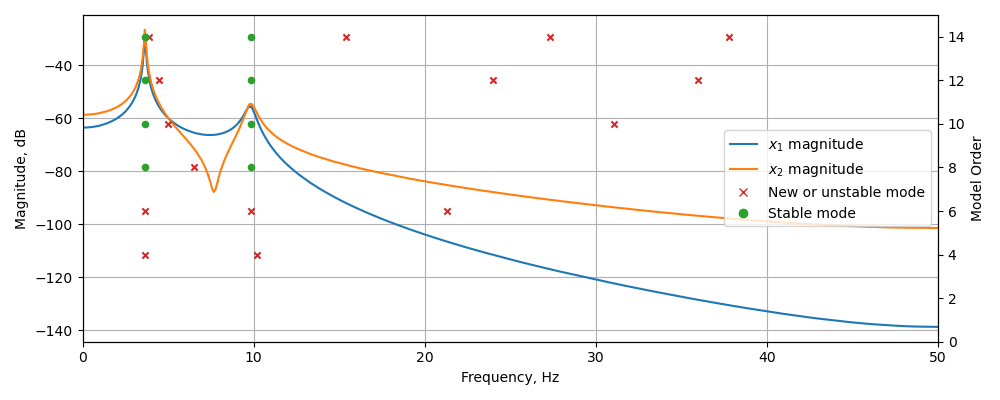

In [21]:
from matplotlib.lines import Line2D  # import Line2D for creating custom legends

# Create figure with two subplots
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot FRF magnitude in the background
# Get positive frequencies only
pos_mask = frequencies >= 0
pos_freqs = frequencies[pos_mask]
# Iterate over each degree of freedom
for i in range(DOF_COUNT):
    # Find positive-frequency portion of the FRF
    pos_spectrum = frf[i, pos_mask]
    # Calculate magnitude
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    # Plot magnitude
    ax1.plot(pos_freqs, magnitude_db)

# Add axes labels and grid
ax1.set_xlabel("Frequency, Hz")
ax1.set_ylabel("Magnitude, dB")
ax1.grid(True)

# Create a second y-axis for the stability information
ax2 = ax1.twinx()

# Plot markers for different stability types
# New modes (not stable)
new_modes = stabilization_results[stabilization_results["stability"] == "new"]
ax2.scatter(new_modes["freq_Hz"], new_modes["order"], s=20, color=COLORS[3], marker="x")

# Fully stable modes
stable_modes = stabilization_results[stabilization_results["stability"] == "stable"]
ax2.scatter(
    stable_modes["freq_Hz"], stable_modes["order"], s=20, color=COLORS[2], marker="o"
)

# Add axis label, limits, and grid
ax2.set_ylabel("Model Order")
ax2.set_xlim([0, f_sampling / 2])
ax2.set_ylim([0, max(order_range) + 1])
ax2.grid(False)

# Create proxy artists for legend
x1_line = Line2D([0], [0], color=COLORS[0], label="$x_1$ magnitude")
x2_line = Line2D([0], [0], color=COLORS[1], label="$x_2$ magnitude")
new_mode = Line2D(
    [0],
    [0],
    color=COLORS[3],
    marker="x",
    linestyle="None",
    label="New or unstable mode",
)
stable_mode = Line2D(
    [0], [0], color=COLORS[2], marker="o", linestyle="None", label="Stable mode"
)

# Add legend
ax1.legend(handles=[x1_line, x2_line, new_mode, stable_mode], loc="center right")

# Set layout and show plot
plt.tight_layout()
plt.show()

As expected, the stabilization diagram clearly shows the physical modes as vertical lines of frequency estimates that coincide with the resonant peaks of the FRF magnitude spectra. These physical modes stabilize from model order 8 onwards, while the spurious modes scatter across the diagram, indicating their computational nature.

Finally, we retrieve the modal parameters and mode shapes from model order 8 and compare them with the true values.

Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 22.92 rad/s
Percentage error: -0.00%
True damping ratio: 0.01
Estimated damping ratio: 0.01
Percentage error: -1.50%

Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 61.71 rad/s
Percentage error: 0.00%
True damping ratio: 0.03
Estimated damping ratio: 0.03
Percentage error: -0.02%



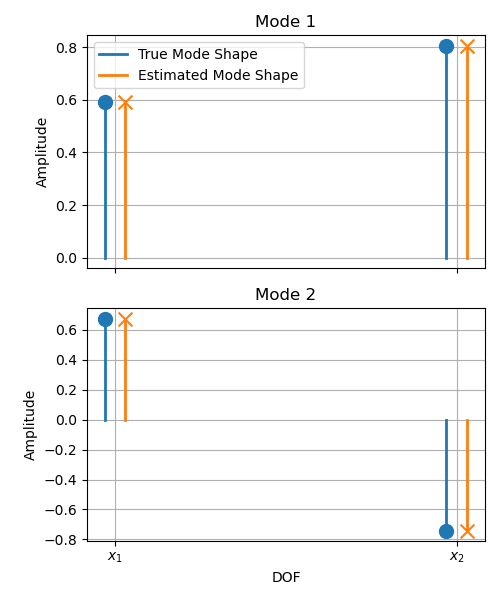

In [22]:
# Get the first stable modes (model order = 8)
first_stable_modes = stabilization_results[
    (stabilization_results["order"] == 8)
    & (stabilization_results["stability"] == "stable")
]

# Initialize array to store estimated mode shapes
estimated_modes = np.zeros((DOF_COUNT, DOF_COUNT))

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(DOF_COUNT):
    estimated_frequency = first_stable_modes.iloc[i]["frequency"]
    estimated_damping = first_stable_modes.iloc[i]["damping"]
    estimated_modes[:, i] = first_stable_modes.iloc[i]["mode_shape"].flatten()
    print(f"Mode {i+1:d}")
    print(f"True natural frequency: {sorted_natural_frequencies[i]:.2f} rad/s")
    print(f"Estimated natural frequency: {estimated_frequency:.2f} rad/s")
    print(
        f"Percentage error: {100 * (estimated_frequency/sorted_natural_frequencies[i] - 1):.2f}%"
    )
    print(f"True damping ratio: {sorted_damping_ratios[i]:.2f}")
    print(f"Estimated damping ratio: {estimated_damping:.2f}")
    print(
        f"Percentage error: {100 * (estimated_damping/sorted_damping_ratios[i] - 1):.2f}%\n"
    )

# Plot true vs estimated mode shapes
plot_mode_shapes(sorted_true_modes, estimated_modes)

Wow, what a result! We now get an almost perfect match for both modes, both for the modal parameters and the mode shapes. The worst result is the damping ratio of the first mode, which is only 1.5% off the true value. The improvement with respect to the previous results is remarkable, and it demonstrates the power of the stabilization diagram approach in identifying the physical modes of a system from random excitation data.

## Conclusions <a name="conclusions"></a>

***

In this notebook, we have explored the challenges and solutions for estimating the modal parameters and mode shapes of a 2-DOF mass-spring-damper system from random excitation data. We have seen how the LSCE algorithm can be used to estimate the modal parameters from the Impulse Response Function (IRF) obtained from the Frequency Response Function (FRF) and how the mode shapes can be calculated from the residues. We have also discussed the limitations of the LSCE algorithm, particularly in the presence of noise, and how the improved FRF calculation approach can mitigate these limitations by using windowing, power spectral densities, and the H1 estimator. Finally, we have introduced the concept of multiple model orders and stabilization criteria to identify the physical modes of a system from random excitation data, and we have shown how this approach can lead to accurate modal parameter estimation.

In the next notebook, we will explore a different method for estimating the modal parameters and mode shapes of our 2-DOF system: the Rational Fraction Polynomial (RFP) method. Contrary to the LSCE algorithm, the RFP method is a frequency-domain technique that directly estimates the poles and residues of the system from the FRF, without the need to calculate the IRF. Stay tuned for more exciting modal analysis techniques!